In [ ]:
# Creating the appropriate environment
pip install unitpackage

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# A quick check to verify that all the relevant tools are available and functional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print ("Everything work")

Everything work


In [ ]:
# Accessing the echemdb documentation via API pattern and inspecting the content of what the API actually returns.
from unitpackage.database.echemdb import Echemdb

db = Echemdb.from_remote(version="0.9.2")
db.describe()

{'number of references': 93,
 'number of entries': 358,
 'materials': {'Ag',
  'Au',
  'Co',
  'Cu',
  'Fe',
  'Ir',
  'Ni',
  'Pb',
  'Pd',
  'Pt',
  'Rh',
  'Ru'}}

In [ ]:
# Narrowing the dataset to Pt, Au electrodes only. Excluding other electrodes besides Pt & Au. Returns the statistical summary.
pt_au_db = db.filter(
    lambda entry: entry.get_electrode("WE").material in ["Pt", "Au"]
)

pt_au_db.describe()

{'number of references': 62,
 'number of entries': 270,
 'materials': {'Au', 'Pt'}}

In [ ]:
# 'Inspecting the detailed output following filtering'
filtered_db = db.filter(
    lambda entry:
        entry.get_electrode("WE").material in ["Pt", "Au"]
        and entry.get_electrode("WE").type == "single crystal"
        and entry.get_electrode("WE").crystallographicOrientation in ["111", "100", "110"]
)

filtered_db.describe()

{'number of references': 53,
 'number of entries': 207,
 'materials': {'Au', 'Pt'}}

In [ ]:
# Verifying the number of entries following the application of the filter
print("Number of filtered entries:", len(filtered_db))

Number of filtered entries: 207


In [ ]:
# Inspecting the crystallographic orientations present for both Pt and Au electrodes
for i, entry in enumerate(filtered_db):
    if i < 5:
        electrode = entry.get_electrode("WE")
        print(
            i,
            electrode.material,
            electrode.type,
            electrode.crystallographicOrientation
        )

0 Pt single crystal 111
1 Pt single crystal 110
2 Pt single crystal 100
3 Au single crystal 111
4 Au single crystal 111


In [ ]:
# Inspecting the metadata structure of one entry
entry = filtered_db[0]

print(entry.metadata["echemdb"]["system"])

{'type': 'electrochemical', 'electrolyte': {'type': 'aqueous', 'components': [{'name': 'water', 'type': 'solvent', 'chemicalIdentifiers': {'cas': '7732-18-5', 'smiles': 'O'}, 'source': {'refinement': 'Millipore Milli Q'}, 'purity': {'grade': 'ultrapure'}}, {'name': 'HClO4', 'type': 'acid', 'chemicalIdentifiers': {'cas': '7601-90-3', 'smiles': 'Cl(=O)(=O)(=O)O'}, 'concentration': {'value': 0.1, 'unit': 'mol / l'}}, {'name': 'N2', 'type': 'gas'}]}, 'electrodes': [{'name': 'REF', 'function': 'reference electrode', 'type': 'RHE'}, {'name': 'WE', 'function': 'working electrode', 'type': 'single crystal', 'crystallographicOrientation': '111', 'material': 'Pt', 'preparationProcedure': {'description': ['Annealed in hydrogen/oxygen flame', 'subsequently cooled in air down to 473 K', 'protected with water', 'immediately transferred into the electrochemical cell.']}}]}


In [9]:
print(entry.metadata["echemdb"]["figureDescription"])

{'type': 'digitized', 'simultaneousMeasurements': [], 'measurementType': 'CV', 'fields': [{'name': 'E', 'type': 'number', 'unit': 'V', 'orientation': 'horizontal', 'reference': 'RHE'}, {'name': 'j', 'type': 'number', 'unit': 'mA / cm2', 'orientation': 'vertical'}], 'comment': '', 'scanRate': {'value': 50.0, 'unit': 'mV / s'}}


In [10]:
db_filtered = db.filter(
    lambda entry: entry.get_electrode("WE").material == "Pt"
)

In [11]:
print(db.identifiers[:5])

['engstfeld_2018_polycrystalline_17743_f4b_1', 'engstfeld_2018_polycrystalline_17743_f4b_2', 'engstfeld_2018_polycrystalline_17743_f4b_3', 'engstfeld_2018_polycrystalline_17743_f4b_4', 'hermann_2021_effect_138279_f5a_black']


In [12]:
print(type(db.identifiers))

<class 'list'>


In [13]:
print(filtered_db.identifiers[:5])

['abe_2019_electro-oxidation_315_f2a1_black', 'abe_2019_electro-oxidation_315_f3a1_black', 'abe_2019_electro-oxidation_315_f4a1_black', 'atkin_2009_afm_13266_f4a_solid', 'atkin_2009_afm_13266_f4b_solid']


In [14]:
print(filtered_db.identifiers[0])
print(filtered_db[0])

abe_2019_electro-oxidation_315_f2a1_black
Echemdb('abe_2019_electro-oxidation_315_f2a1_black')


In [15]:
test_metadata = filtered_db[0].metadata["echemdb"].to_builtin()

print(type(test_metadata))
print(type(test_metadata["figureDescription"]))
print(test_metadata["figureDescription"])

<class 'dict'>
<class 'dict'>
{'type': 'digitized', 'simultaneousMeasurements': [], 'measurementType': 'CV', 'fields': [{'name': 'E', 'type': 'number', 'unit': 'V', 'orientation': 'horizontal', 'reference': 'RHE'}, {'name': 'j', 'type': 'number', 'unit': 'mA / cm2', 'orientation': 'vertical'}], 'comment': '', 'scanRate': {'value': 50.0, 'unit': 'mV / s'}}


In [ ]:
# Converting the 207 echemdb entries inti a structured DataFrame via importing Pandas
import pandas as pd

records = []

for entry_id, entry in zip(filtered_db.identifiers, filtered_db):

    # Convert unitpackage metadata into ordinary Python objects
    metadata = entry.metadata["echemdb"].to_builtin()

    system = metadata["system"]
    figure = metadata["figureDescription"]

    # Find the working electrode
    we = next(
        electrode
        for electrode in system["electrodes"]
        if electrode["name"] == "WE"
    )

    # Potential/current fields
    fields = figure.get("fields", [])

    potential = fields[0] if len(fields) > 0 else {}
    current = fields[1] if len(fields) > 1 else {}

    # Scan rate
    scan_rate = figure.get("scanRate", {})

    records.append({
        "entry_id": entry_id,

        # Electrode
        "material": we.get("material"),
        "electrode_type": we.get("type"),
        "orientation": we.get("crystallographicOrientation"),

        # Measurement
        "measurement_type": figure.get("measurementType"),

        # Scan rate
        "scan_rate_value": scan_rate.get("value"),
        "scan_rate_unit": scan_rate.get("unit"),

        # Potential
        "potential_name": potential.get("name"),
        "potential_unit": potential.get("unit"),
        "potential_reference": potential.get("reference"),

        # Current
        "current_name": current.get("name"),
        "current_unit": current.get("unit"),
    })

df = pd.DataFrame(records)

df.head()

,entry_id,material,electrode_type,orientation,measurement_type,scan_rate_value,scan_rate_unit,potential_name,potential_unit,potential_reference,current_name,current_unit
0,abe_2019_electro-oxidation_315_f2a1_black,Pt,single crystal,111,CV,50.0,mV / s,E,V,RHE,j,mA / cm2
1,abe_2019_electro-oxidation_315_f3a1_black,Pt,single crystal,110,CV,50.0,mV / s,E,V,RHE,j,mA / cm2
2,abe_2019_electro-oxidation_315_f4a1_black,Pt,single crystal,100,CV,50.0,mV / s,E,V,RHE,j,mA / cm2
3,atkin_2009_afm_13266_f4a_solid,Au,single crystal,111,CV,10.0,mV / s,E,V,Fc/Fc+,j,mA / cm2
4,atkin_2009_afm_13266_f4b_solid,Au,single crystal,111,CV,10.0,mV / s,E,V,Fc/Fc+,j,mA / cm2


In [ ]:
# A quick check of the basic structure of the DataFrame
print("Shape:", df.shape)

Shape: (207, 12)


In [ ]:
# Coming to terms with the various column names present in the DataFrame
print("\ncolumns:")
print(df.columns.tolist())

['entry_id', 'material', 'electrode_type', 'orientation', 'measurement_type', 'scan_rate_value', 'scan_rate_unit', 'potential_name', 'potential_unit', 'potential_reference', 'current_name', 'current_unit']


In [ ]:
# Getting an overview on the imported data types and check for completeness
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   entry_id             207 non-null    str    
 1   material             207 non-null    str    
 2   electrode_type       207 non-null    str    
 3   orientation          207 non-null    str    
 4   measurement_type     207 non-null    str    
 5   scan_rate_value      207 non-null    float64
 6   scan_rate_unit       207 non-null    str    
 7   potential_name       207 non-null    str    
 8   potential_unit       207 non-null    str    
 9   potential_reference  201 non-null    str    
 10  current_name         207 non-null    str    
 11  current_unit         207 non-null    str    
dtypes: float64(1), str(11)
memory usage: 35.3 KB


In [ ]:
# Checking if there are any missing values
df.isna().sum()

entry_id               0
material               0
electrode_type         0
orientation            0
measurement_type       0
scan_rate_value        0
scan_rate_unit         0
potential_name         0
potential_unit         0
potential_reference    6
current_name           0
current_unit           0
dtype: int64

In [21]:
# Inspect the metadata structure of the first filtered entry

metadata = filtered_db[0].metadata["echemdb"].to_builtin()

print(metadata.keys())

print("\nSYSTEM KEYS:")
print(metadata["system"].keys())

print("\nELECTROLYTE:")
print(metadata["system"]["electrolyte"])

print("\nELECTRODES:")
for electrode in metadata["system"]["electrodes"]:
    print(electrode)

print("\nSOURCE:")
print(metadata["source"])

dict_keys(['curation', 'source', 'experimental', 'system', 'figureDescription', 'echemdbSchemaVersion'])

SYSTEM KEYS:
dict_keys(['type', 'electrolyte', 'electrodes'])

ELECTROLYTE:
{'type': 'aqueous', 'components': [{'name': 'water', 'type': 'solvent', 'chemicalIdentifiers': {'cas': '7732-18-5', 'smiles': 'O'}, 'source': {'refinement': 'Millipore Milli Q'}, 'purity': {'grade': 'ultrapure'}}, {'name': 'HClO4', 'type': 'acid', 'chemicalIdentifiers': {'cas': '7601-90-3', 'smiles': 'Cl(=O)(=O)(=O)O'}, 'concentration': {'value': 0.1, 'unit': 'mol / l'}}, {'name': 'N2', 'type': 'gas'}]}

ELECTRODES:
{'name': 'REF', 'function': 'reference electrode', 'type': 'RHE'}
{'name': 'WE', 'function': 'working electrode', 'type': 'single crystal', 'crystallographicOrientation': '111', 'material': 'Pt', 'preparationProcedure': {'description': ['Annealed in hydrogen/oxygen flame', 'subsequently cooled in air down to 473 K', 'protected with water', 'immediately transferred into the electrochemical cell.'

In [ ]:
# Inspecting several entries
for i in range(5):
    entry_id = filtered_db.identifiers[i]
    metadata = filtered_db[i].metadata["echemdb"].to_builtin()

    print("\n" + "=" * 80)
    print("ENTRY:", entry_id)

    print("\nElectrolyte:")
    print(metadata["system"].get("electrolyte"))

    print("\nElectrodes:")
    for electrode in metadata["system"].get("electrodes", []):
        print(
            electrode.get("name"),
            "|",
            electrode.get("function"),
            "|",
            electrode.get("type"),
            "|",
            electrode.get("material")
        )

    print("\nSource:")
    print(metadata["source"].get("citationKey"))
    print(metadata["source"].get("url"))
    print(metadata["source"].get("figure"))
    print(metadata["source"].get("curve"))


ENTRY: abe_2019_electro-oxidation_315_f2a1_black

Electrolyte:
{'type': 'aqueous', 'components': [{'name': 'water', 'type': 'solvent', 'chemicalIdentifiers': {'cas': '7732-18-5', 'smiles': 'O'}, 'source': {'refinement': 'Millipore Milli Q'}, 'purity': {'grade': 'ultrapure'}}, {'name': 'HClO4', 'type': 'acid', 'chemicalIdentifiers': {'cas': '7601-90-3', 'smiles': 'Cl(=O)(=O)(=O)O'}, 'concentration': {'value': 0.1, 'unit': 'mol / l'}}, {'name': 'N2', 'type': 'gas'}]}

Electrodes:
REF | reference electrode | RHE | None
WE | working electrode | single crystal | Pt

Source:
abe_2019_electro-oxidation_315
https://doi.org/10.3390/surfaces2020023
2a1
black

ENTRY: abe_2019_electro-oxidation_315_f3a1_black

Electrolyte:
{'type': 'aqueous', 'components': [{'name': 'water', 'type': 'solvent', 'chemicalIdentifiers': {'cas': '7732-18-5', 'smiles': 'O'}, 'source': {'refinement': 'Millipore Milli Q'}, 'purity': {'grade': 'ultrapure'}}, {'name': 'HClO4', 'type': 'acid', 'chemicalIdentifiers': {'cas':

In [ ]:
# Checking the categorical distributions
print("MATERIALS")
print(df["material"].value_counts())

print("\nORIENTATIONS")
print(df["orientation"].value_counts())

print("\nMEASUREMENT TYPES")
print(df["measurement_type"].value_counts())

print("\nSCAN RATE UNITS")
print(df["scan_rate_unit"].value_counts())

print("\nPOTENTIAL REFERENCES")
print(df["potential_reference"].value_counts(dropna=False))

print("\nCURRENT UNITS")
print(df["current_unit"].value_counts())

MATERIALS
material
Pt    115
Au     92
Name: count, dtype: int64

ORIENTATIONS
orientation
111    176
100     19
110     12
Name: count, dtype: int64

MEASUREMENT TYPES
measurement_type
CV    207
Name: count, dtype: int64

SCAN RATE UNITS
scan_rate_unit
mV / s    207
Name: count, dtype: int64

POTENTIAL REFERENCES
potential_reference
RHE        88
SCE        45
SHE        16
Pt         15
Fc/Fc+     10
Ag/AgCl    10
Ag          7
NaN         6
Li/Li+      5
I-/I3-      4
Zn/Zn2+     1
Name: count, dtype: int64

CURRENT UNITS
current_unit
uA / cm2    161
mA / cm2     14
µA cm⁻²      13
uA            8
V             6
mA            3
uA cm-2       1
nA / cm2      1
Name: count, dtype: int64


In [24]:
print("\nSCAN RATE SUMMARY")
print(df["scan_rate_value"].describe())


SCAN RATE SUMMARY
count    207.000000
mean      38.381643
std       23.687165
min        5.000000
25%       10.000000
50%       50.000000
75%       50.000000
max      100.000000
Name: scan_rate_value, dtype: float64


In [ ]:
# Now, the extraction of the dataset begins
import pandas as pd
import re

records = []

for entry_id, entry in zip(filtered_db.identifiers, filtered_db):

    metadata = entry.metadata["echemdb"].to_builtin()

    system = metadata.get("system", {})
    figure = metadata.get("figureDescription", {})
    source = metadata.get("source", {})

    # ---------------------------------------------------------
    # Working, reference and counter electrodes
    # ---------------------------------------------------------
    electrodes = system.get("electrodes", [])

    we = next(
        (e for e in electrodes if e.get("name") == "WE"),
        {}
    )

    ref = next(
        (e for e in electrodes if e.get("name") == "REF"),
        {}
    )

    ce = next(
        (e for e in electrodes if e.get("name") == "CE"),
        {}
    )

    # ---------------------------------------------------------
    # Electrolyte
    # ---------------------------------------------------------
    electrolyte = system.get("electrolyte", {})

    electrolyte_type = electrolyte.get("type")

    components = electrolyte.get("components", [])

    component_names = []
    solvent_names = []
    gas_names = []
    concentrations = []

    for component in components:

        name = component.get("name")
        component_type = component.get("type")

        if name:
            component_names.append(name)

        if component_type == "solvent":
            if name:
                solvent_names.append(name)

        if component_type == "gas":
            if name:
                gas_names.append(name)

        concentration = component.get("concentration")

        if concentration:
            concentrations.append({
                "name": name,
                "value": concentration.get("value"),
                "unit": concentration.get("unit")
            })

    # ---------------------------------------------------------
    # CV fields
    # ---------------------------------------------------------
    fields = figure.get("fields", [])

    potential = fields[0] if len(fields) > 0 else {}
    current = fields[1] if len(fields) > 1 else {}

    scan_rate = figure.get("scanRate", {})

    # ---------------------------------------------------------
    # Publication information
    # ---------------------------------------------------------
    citation_key = source.get("citationKey")
    doi_url = source.get("url")
    figure_name = source.get("figure")
    curve = source.get("curve")

    # Extract publication year from BibTeX
    bibdata = source.get("bibdata", "")
    year_match = re.search(r'year\s*=\s*"(\d{4})"', bibdata)
    publication_year = int(year_match.group(1)) if year_match else None

    # ---------------------------------------------------------
    # Create record
    # ---------------------------------------------------------
    records.append({

        # Identification
        "entry_id": entry_id,

        # Electrode
        "material": we.get("material"),
        "electrode_type": we.get("type"),
        "orientation": we.get("crystallographicOrientation"),

        # Reference / counter electrode
        "reference_electrode": ref.get("type"),
        "reference_material": ref.get("material"),
        "counter_electrode": ce.get("material"),

        # Measurement
        "measurement_type": figure.get("measurementType"),

        # Scan rate
        "scan_rate_value": scan_rate.get("value"),
        "scan_rate_unit": scan_rate.get("unit"),

        # Potential
        "potential_name": potential.get("name"),
        "potential_unit": potential.get("unit"),
        "potential_reference": potential.get("reference"),

        # Current
        "current_name": current.get("name"),
        "current_unit": current.get("unit"),

        # Electrolyte
        "electrolyte_type": electrolyte_type,
        "electrolyte_components": "; ".join(component_names),
        "solvent": "; ".join(solvent_names) if solvent_names else None,
        "gas": "; ".join(gas_names) if gas_names else None,

        # Concentration information
        "concentrations": "; ".join(
            f"{c['name']}: {c['value']} {c['unit']}"
            for c in concentrations
        ) if concentrations else None,

        # Publication
        "citation_key": citation_key,
        "doi_url": doi_url,
        "figure": figure_name,
        "curve": curve,
        "publication_year": publication_year
    })


df_rich = pd.DataFrame(records)

print("Shape:", df_rich.shape)

df_rich.head()

Shape: (207, 25)


,entry_id,material,electrode_type,orientation,reference_electrode,reference_material,counter_electrode,measurement_type,scan_rate_value,scan_rate_unit,...,electrolyte_type,electrolyte_components,solvent,gas,concentrations,citation_key,doi_url,figure,curve,publication_year
0,abe_2019_electro-oxidation_315_f2a1_black,Pt,single crystal,111,RHE,NaN,NaN,CV,50.0,mV / s,...,aqueous,water; HClO4; N2,water,N2,HClO4: 0.1 mol / l,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,2a1,black,2019
1,abe_2019_electro-oxidation_315_f3a1_black,Pt,single crystal,110,RHE,NaN,NaN,CV,50.0,mV / s,...,aqueous,water; HClO4; N2,water,N2,HClO4: 0.1 mol / l,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,3a1,black,2019
2,abe_2019_electro-oxidation_315_f4a1_black,Pt,single crystal,100,RHE,NaN,NaN,CV,50.0,mV / s,...,aqueous,water; HClO4; N2,water,N2,HClO4: 0.1 mol / l,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,4a1,black,2019
3,atkin_2009_afm_13266_f4a_solid,Au,single crystal,111,NaN,Pt,Pt,CV,10.0,mV / s,...,ionic liquid,BMPyr-TFSI,BMPyr-TFSI,NaN,NaN,atkin_2009_afm_13266,https://doi.org/10.1021/jp9026755,4a,solid,2009
4,atkin_2009_afm_13266_f4b_solid,Au,single crystal,111,NaN,Pt,Pt,CV,10.0,mV / s,...,ionic liquid,EMIm-TFSI,EMIm-TFSI,NaN,NaN,atkin_2009_afm_13266,https://doi.org/10.1021/jp9026755,4b,solid,2009


In [ ]:
# A quick inspection of the new dataset
df_rich.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   entry_id                207 non-null    str    
 1   material                207 non-null    str    
 2   electrode_type          207 non-null    str    
 3   orientation             207 non-null    str    
 4   reference_electrode     159 non-null    str    
 5   reference_material      42 non-null     str    
 6   counter_electrode       170 non-null    str    
 7   measurement_type        207 non-null    str    
 8   scan_rate_value         207 non-null    float64
 9   scan_rate_unit          207 non-null    str    
 10  potential_name          207 non-null    str    
 11  potential_unit          207 non-null    str    
 12  potential_reference     201 non-null    str    
 13  current_name            207 non-null    str    
 14  current_unit            207 non-null    str    
 15  

In [ ]:
# Check to see if there are any missing values
print("\nMissing values:")
print(df_rich.isna().sum())


Missing values:
entry_id                    0
material                    0
electrode_type              0
orientation                 0
reference_electrode        48
reference_material        165
counter_electrode          37
measurement_type            0
scan_rate_value             0
scan_rate_unit              0
potential_name              0
potential_unit              0
potential_reference         6
current_name                0
current_unit                0
electrolyte_type            0
electrolyte_components      0
solvent                     0
gas                       189
concentrations             43
citation_key                0
doi_url                     0
figure                      0
curve                       0
publication_year            0
dtype: int64


In [28]:
print(df_rich.isna().sum())

entry_id                    0
material                    0
electrode_type              0
orientation                 0
reference_electrode        48
reference_material        165
counter_electrode          37
measurement_type            0
scan_rate_value             0
scan_rate_unit              0
potential_name              0
potential_unit              0
potential_reference         6
current_name                0
current_unit                0
electrolyte_type            0
electrolyte_components      0
solvent                     0
gas                       189
concentrations             43
citation_key                0
doi_url                     0
figure                      0
curve                       0
publication_year            0
dtype: int64


In [ ]:
# Checking the value counts of several parameters and the differnt types of similar parameters present in the dataset
print("\nElectrolyte types:")
print(df_rich["electrolyte_type"].value_counts(dropna=False))

print("\nReference electrodes:")
print(df_rich["reference_electrode"].value_counts(dropna=False))

print("\nSolvents:")
print(df_rich["solvent"].value_counts(dropna=False))

print("\nPublication years:")
print(df_rich["publication_year"].value_counts().sort_index())


Electrolyte types:
electrolyte_type
aqueous         162
ionic liquid     45
Name: count, dtype: int64

Reference electrodes:
reference_electrode
RHE                                         82
NaN                                         48
SCE                                         39
Ag/AgCl                                     15
wire                                         5
Pt wire                                      4
Ag/AgCl-sat                                  4
Ag/AgCl_3M                                   3
microreference                               2
Pt                                           2
SCE-sat                                      1
leakless ag/agcl-3.4m kcl edaq electrode     1
sheet                                        1
Name: count, dtype: int64

Solvents:
solvent
water         148
BMPyr-TFSI     14
H2O            14
EMIm-TFSI      12
EMIm-FAP        4
MPPip-TFSI      4
BMPyr-FAP       3
BMIm-BF4        3
BMIm-PF6        2
EMIm-TFA        1
EMIm-TAc        1


In [ ]:
# Identifying the 6 items that have current units of V
df_rich.loc[
    df_rich["current_unit"] == "V",
    [
        "entry_id",
        "material",
        "orientation",
        "current_name",
        "current_unit",
        "potential_name",
        "potential_unit",
        "potential_reference",
        "citation_key",
        "figure",
        "curve"
    ]
]

,entry_id,material,orientation,current_name,current_unit,potential_name,potential_unit,potential_reference,citation_key,figure,curve
111,hermann_2021_effect_138279_f5a_black,Au,111,E,V,t,s,NaN,hermann_2021_effect_138279,5a,black
112,hermann_2021_effect_138279_f5a_blue,Au,111,E,V,t,s,NaN,hermann_2021_effect_138279,5a,blue
113,hermann_2021_effect_138279_f5a_green,Au,111,E,V,t,s,NaN,hermann_2021_effect_138279,5a,green
114,hermann_2021_effect_138279_f5a_orange,Au,111,E,V,t,s,NaN,hermann_2021_effect_138279,5a,orange
115,hermann_2021_effect_138279_f5a_red,Au,111,E,V,t,s,NaN,hermann_2021_effect_138279,5a,red
116,hermann_2021_effect_138279_f5a_violet,Au,111,E,V,t,s,NaN,hermann_2021_effect_138279,5a,violet


In [ ]:
# Inspecting all other current units displayed in the code output
usual_units = [
    "uA / cm2",
    "mA / cm2",
    "µA cm⁻²",
    "uA cm-2",
    "nA / cm2"
]

df_rich.loc[
    ~df_rich["current_unit"].isin(usual_units),
    [
        "entry_id",
        "current_name",
        "current_unit",
        "potential_name",
        "potential_unit"
    ]
]

,entry_id,current_name,current_unit,potential_name,potential_unit
18,bonhote_1996_hydrophobic_1168_f7_bold,I,uA,E,V
19,bonhote_1996_hydrophobic_1168_f7_dashed,I,uA,E,V
20,bonhote_1996_hydrophobic_1168_f7_dotdashed,I,uA,E,V
21,bonhote_1996_hydrophobic_1168_f7_solid,I,uA,E,V
22,borisenko_2006_situ_6250_f1_a,I,uA,E,V
23,borisenko_2006_situ_6250_f1_b,I,uA,E,V
24,borisenko_2006_situ_6250_f1_c,I,uA,E,V
90,durand_1992_situ_1977_f1a_solid,I,uA,E,V
91,endres_2006_probing_1377_f11_a,I,mA,E,V
92,endres_2006_probing_1377_f11_b,I,mA,E,V


In [ ]:
# Make a working copy of the DataFrame
df_master = df_rich.copy()

print("Shape:", df_master.shape)

Shape: (207, 25)


In [ ]:
# Standardize string columns or the text fields
text_columns = [
    "material",
    "electrode_type",
    "orientation",
    "measurement_type",
    "scan_rate_unit",
    "potential_name",
    "potential_unit",
    "potential_reference",
    "current_name",
    "current_unit",
    "electrolyte_type",
    "solvent",
    "gas",
    "citation_key",
    "doi_url",
    "figure",
    "curve"
]

for col in text_columns:
    if col in df_master.columns:
        df_master[col] = df_master[col].astype("string").str.strip()

In [ ]:
# Create scan_rate_categories
def categorize_scan_rate(value):
    if pd.isna(value):
        return pd.NA
    elif value <= 10:
        return "Low"
    elif value <= 50:
        return "Medium"
    else:
        return "High"


df_master["scan_rate_category"] = (
    df_master["scan_rate_value"]
    .apply(categorize_scan_rate)
)

In [ ]:
# Check the output of the created scan_rate_categories
print(df_master["scan_rate_category"].value_counts())

scan_rate_category
Medium    131
Low        65
High       11
Name: count, dtype: int64


In [ ]:
# Create a cleaner electrolyte description
df_master["electrolyte_condition"] = (
    df_master["electrolyte_components"]
    .fillna("Unknown")
    .str.replace(";", " + ", regex=False)
)

In [ ]:
# Extract a primary electrolyte concentration
def extract_first_concentration(value):
    if pd.isna(value):
        return pd.Series([pd.NA, pd.NA])

    match = re.search(
        r":\s*([-+]?\d*\.?\d+)\s*(.*)",
        str(value)
    )

    if match:
        return pd.Series([
            float(match.group(1)),
            match.group(2).strip()
        ])

    return pd.Series([pd.NA, pd.NA])


df_master[
    ["concentration_value", "concentration_unit"]
] = df_master["concentrations"].apply(
    extract_first_concentration
)

In [ ]:
# A quick check of the first 10 electrolyte description output 
df_master[
    [
        "electrolyte_components",
        "concentrations",
        "concentration_value",
        "concentration_unit"
    ]
].head(10)

,electrolyte_components,concentrations,concentration_value,concentration_unit
0,water; HClO4; N2,HClO4: 0.1 mol / l,0.1,mol / l
1,water; HClO4; N2,HClO4: 0.1 mol / l,0.1,mol / l
2,water; HClO4; N2,HClO4: 0.1 mol / l,0.1,mol / l
3,BMPyr-TFSI,NaN,<NA>,NaN
4,EMIm-TFSI,NaN,<NA>,NaN
5,BMPyr-FAP,NaN,<NA>,NaN
6,BMPyr-FAP,NaN,<NA>,NaN
7,EMIm-FAP,NaN,<NA>,NaN
8,BMPyr-FAP,NaN,<NA>,NaN
9,MPPip-TFSI; Li-TFSI,Li-TFSI: 0.02 mol / l,0.02,mol / l


# The EDA (data extraction) has been successful. Now, we transition to polishing, cleaning, normalizing, etc the dataset in phases.
Phase 1 will create the final cleaned master DataFrame

In [ ]:
# Add a measurement ID; the entry ID originates from echemdb
df_master.insert(
    0,
    "measurement_id",
    range(1, len(df_master) + 1)
)

In [ ]:
# Master data validation
print("Shape:", df_master.shape)

print("\nColumns:")
print(df_master.columns.tolist())

print("\nMissing values:")
print(df_master.isna().sum())

Shape: (207, 30)

Columns:
['measurement_id', 'entry_id', 'material', 'electrode_type', 'orientation', 'reference_electrode', 'reference_material', 'counter_electrode', 'measurement_type', 'scan_rate_value', 'scan_rate_unit', 'potential_name', 'potential_unit', 'potential_reference', 'current_name', 'current_unit', 'electrolyte_type', 'electrolyte_components', 'solvent', 'gas', 'concentrations', 'citation_key', 'doi_url', 'figure', 'curve', 'publication_year', 'scan_rate_category', 'electrolyte_condition', 'concentration_value', 'concentration_unit']

Missing values:
measurement_id              0
entry_id                    0
material                    0
electrode_type              0
orientation                 0
reference_electrode        48
reference_material        165
counter_electrode          37
measurement_type            0
scan_rate_value             0
scan_rate_unit              0
potential_name              0
potential_unit              0
potential_reference         6
curren

In [ ]:
# check the first few rows of the master DataFrame
df_master.head()

,measurement_id,entry_id,material,electrode_type,orientation,reference_electrode,reference_material,counter_electrode,measurement_type,scan_rate_value,...,concentrations,citation_key,doi_url,figure,curve,publication_year,scan_rate_category,electrolyte_condition,concentration_value,concentration_unit
0,1,abe_2019_electro-oxidation_315_f2a1_black,Pt,single crystal,111,RHE,NaN,NaN,CV,50.0,...,HClO4: 0.1 mol / l,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,2a1,black,2019,Medium,water + HClO4 + N2,0.1,mol / l
1,2,abe_2019_electro-oxidation_315_f3a1_black,Pt,single crystal,110,RHE,NaN,NaN,CV,50.0,...,HClO4: 0.1 mol / l,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,3a1,black,2019,Medium,water + HClO4 + N2,0.1,mol / l
2,3,abe_2019_electro-oxidation_315_f4a1_black,Pt,single crystal,100,RHE,NaN,NaN,CV,50.0,...,HClO4: 0.1 mol / l,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,4a1,black,2019,Medium,water + HClO4 + N2,0.1,mol / l
3,4,atkin_2009_afm_13266_f4a_solid,Au,single crystal,111,NaN,Pt,Pt,CV,10.0,...,NaN,atkin_2009_afm_13266,https://doi.org/10.1021/jp9026755,4a,solid,2009,Low,BMPyr-TFSI,<NA>,NaN
4,5,atkin_2009_afm_13266_f4b_solid,Au,single crystal,111,NaN,Pt,Pt,CV,10.0,...,NaN,atkin_2009_afm_13266,https://doi.org/10.1021/jp9026755,4b,solid,2009,Low,EMIm-TFSI,<NA>,NaN


# Phase 2 of the polishing stage. Create normalized lookup tables.

In [ ]:
# Create Table 1 - materials
materials = (
    df_master[["material"]]
    .drop_duplicates()
    .sort_values("material")
    .reset_index(drop=True)
)

materials.insert(
    0,
    "material_id",
    range(1, len(materials) + 1)
)

materials

,material_id,material
0,1,Au
1,2,Pt


In [ ]:
# Rename the column
materials = materials.rename(
    columns={"material": "material_name"}
)

In [ ]:
# Create Table 2 - orientations
orientations = (
    df_master[["orientation"]]
    .drop_duplicates()
    .sort_values("orientation")
    .reset_index(drop=True)
)

orientations.insert(
    0,
    "orientation_id",
    range(1, len(orientations) + 1)
)

orientations = orientations.rename(
    columns={"orientation": "orientation_name"}
)

orientations

,orientation_id,orientation_name
0,1,100
1,2,110
2,3,111


In [ ]:
# Create Table 3 - sources
sources = (
    df_master[
        [
            "citation_key",
            "doi_url",
            "publication_year"
        ]
    ]
    .drop_duplicates()
    .sort_values("citation_key")
    .reset_index(drop=True)
)

sources.insert(
    0,
    "source_id",
    range(1, len(sources) + 1)
)

sources

,source_id,citation_key,doi_url,publication_year
0,1,abe_2019_electro-oxidation_315,https://doi.org/10.3390/surfaces2020023,2019
1,2,atkin_2009_afm_13266,https://doi.org/10.1021/jp9026755,2009
2,3,atkin_2011_situ_6849,https://doi.org/10.1039/c0cp02846k,2011
3,4,atkin_2014_structure_44,https://doi.org/10.1016/j.molliq.2013.08.006,2014
4,5,berger_2017_lithium_261,https://doi.org/10.1002/celc.201600730,2017
5,6,bi_2018_minimizing_1,https://doi.org/10.1038/s41467-018-07674-0,2018
6,7,bonhote_1996_hydrophobic_1168,https://doi.org/10.1021/ic951325x,1996
7,8,borisenko_2006_situ_6250,https://doi.org/10.1021/jp057337d,2006
8,9,borisenko_2012_situ_1736,https://doi.org/10.1002/cphc.201100873,2012
9,10,briega-martos_2018_understandings_j3045,https://doi.org/10.1149/2.0081815jes,2018


In [ ]:
# Create Table 4 - electrolytes
electrolytes = (
    df_master[
        [
            "electrolyte_type",
            "electrolyte_condition",
            "solvent",
            "gas",
            "concentrations"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["electrolyte_type", "electrolyte_condition"],
        na_position="last"
    )
    .reset_index(drop=True)
)

electrolytes.insert(
    0,
    "electrolyte_id",
    range(1, len(electrolytes) + 1)
)

electrolytes

,electrolyte_id,electrolyte_type,electrolyte_condition,solvent,gas,concentrations
0,1,aqueous,CsF + water + HClO4,water,<NA>,CsF: 0.1 mol / l; HClO4: None mol / l
1,2,aqueous,CsI + water,water,<NA>,CsI: 0.01 mol / l
2,3,aqueous,H2O + H2SO4,H2O,<NA>,H2SO4: 0.1 mol / l
3,4,aqueous,H2O + H2SO4,H2O,<NA>,H2SO4: 1.0 mol / l
4,5,aqueous,H2O + H2SO4,H2O,<NA>,H2SO4: 2.5 mol / l
...,...,...,...,...,...,...
105,106,ionic liquid,EMIm-TFSI,EMIm-TFSI,<NA>,NaN
106,107,ionic liquid,EMIm-TFSI + Li-TFSI,EMIm-TFSI,<NA>,Li-TFSI: 0.5 mol / l
107,108,ionic liquid,EMMIm-TFSI,EMMIm-TFSI,<NA>,NaN
108,109,ionic liquid,MPPip-TFSI,MPPip-TFSI,<NA>,NaN


# Phase 3 invlolves creating the central measurements table, whicch links the other tables.

In [ ]:
# First, mappingg dictionaries are created
material_map = dict(
    zip(
        materials["material_name"],
        materials["material_id"]
    )
)

orientation_map = dict(
    zip(
        orientations["orientation_name"],
        orientations["orientation_id"]
    )
)

source_map = dict(
    zip(
        sources["citation_key"],
        sources["source_id"]
    )
)

In [ ]:
# For electrolytes, several columns are involved since the condition depends on a combination of several conditions
electrolyte_map = {
    (
        row["electrolyte_type"],
        row["electrolyte_condition"],
        row["solvent"],
        row["gas"],
        row["concentrations"]
    ): row["electrolyte_id"]
    for _, row in electrolytes.iterrows()
}

In [ ]:
# Create the measurements table
measurements = df_master.copy()

measurements["material_id"] = measurements["material"].map(
    material_map
)

measurements["orientation_id"] = measurements["orientation"].map(
    orientation_map
)

measurements["source_id"] = measurements["citation_key"].map(
    source_map
)

measurements["electrolyte_id"] = measurements.apply(
    lambda row: electrolyte_map[
        (
            row["electrolyte_type"],
            row["electrolyte_condition"],
            row["solvent"],
            row["gas"],
            row["concentrations"]
        )
    ],
    axis=1
)

In [ ]:
# Select the actual database columns to create Table 5
measurements = measurements[
    [
        "measurement_id",
        "entry_id",

        "material_id",
        "orientation_id",
        "electrolyte_id",
        "source_id",

        "electrode_type",

        "reference_electrode",
        "reference_material",
        "counter_electrode",

        "measurement_type",

        "scan_rate_value",
        "scan_rate_unit",
        "scan_rate_category",

        "potential_name",
        "potential_unit",
        "potential_reference",

        "current_name",
        "current_unit"
    ]
].copy()

# Now, it is appropriate to validate the relational structure in this phase - Phase 4.

In [ ]:
# A quick check of the length of the created tables
print("Materials:", len(materials))
print("Orientations:", len(orientations))
print("Sources:", len(sources))
print("Electrolytes:", len(electrolytes))
print("Measurements:", len(measurements))

Materials: 2
Orientations: 3
Sources: 53
Electrolytes: 110
Measurements: 207


In [ ]:
# Check if there are any missing values
print("\nMissing foreign keys:")

print(
    "material_id:",
    measurements["material_id"].isna().sum()
)

print(
    "orientation_id:",
    measurements["orientation_id"].isna().sum()
)

print(
    "electrolyte_id:",
    measurements["electrolyte_id"].isna().sum()
)

print(
    "source_id:",
    measurements["source_id"].isna().sum()
)


Missing foreign keys:
material_id: 0
orientation_id: 0
electrolyte_id: 0
source_id: 0


In [53]:
print("\nMeasurement IDs unique:")
print(measurements["measurement_id"].is_unique)

print("\nEntry IDs unique:")
print(measurements["entry_id"].is_unique)


Measurement IDs unique:
True

Entry IDs unique:
True


# At this stage or phase, we are ceratin that our 5 tables for the intended database have very clean architecture

In [ ]:
# Fix the electrolyte concentration representation
def format_concentrations(value):
    """
    Clean the concentration representation.
    Removes components where concentration is missing.
    """
    if pd.isna(value):
        return pd.NA

    parts = str(value).split(";")

    cleaned = []

    for part in parts:
        part = part.strip()

        # Ignore entries such as "HClO4: None mol / l"
        if ": None" in part:
            continue

        if part:
            cleaned.append(part)

    if not cleaned:
        return pd.NA

    return "; ".join(cleaned)


df_master["concentrations"] = (
    df_master["concentrations"]
    .apply(format_concentrations)
)

In [ ]:
# Inspect the first 20 electrolyte component output
df_master[
    [
        "electrolyte_components",
        "concentrations"
    ]
].head(20)

,electrolyte_components,concentrations
0,water; HClO4; N2,HClO4: 0.1 mol / l
1,water; HClO4; N2,HClO4: 0.1 mol / l
2,water; HClO4; N2,HClO4: 0.1 mol / l
3,BMPyr-TFSI,NaN
4,EMIm-TFSI,NaN
5,BMPyr-FAP,NaN
6,BMPyr-FAP,NaN
7,EMIm-FAP,NaN
8,BMPyr-FAP,NaN
9,MPPip-TFSI; Li-TFSI,Li-TFSI: 0.02 mol / l


In [ ]:
# Rebuild the electrolyte table
# df_master ["concentrations"] was changed. Therefore, rebuild electrolytes and its mapping 
electrolytes = (
    df_master[
        [
            "electrolyte_type",
            "electrolyte_condition",
            "solvent",
            "gas",
            "concentrations"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["electrolyte_type", "electrolyte_condition"],
        na_position="last"
    )
    .reset_index(drop=True)
)

electrolytes.insert(
    0,
    "electrolyte_id",
    range(1, len(electrolytes) + 1)
)

In [ ]:
# Recreate electrolyte mapping
electrolyte_map = {
    (
        row["electrolyte_type"],
        row["electrolyte_condition"],
        row["solvent"],
        row["gas"],
        row["concentrations"]
    ): row["electrolyte_id"]
    for _, row in electrolytes.iterrows()
}

In [ ]:
# Rebuild the foreign key (FK) in measurements
measurements["electrolyte_id"] = measurements.apply(
    lambda row: electrolyte_map[
        (
            df_master.loc[
                df_master["measurement_id"] == row["measurement_id"],
                "electrolyte_type"
            ].iloc[0],

            df_master.loc[
                df_master["measurement_id"] == row["measurement_id"],
                "electrolyte_condition"
            ].iloc[0],

            df_master.loc[
                df_master["measurement_id"] == row["measurement_id"],
                "solvent"
            ].iloc[0],

            df_master.loc[
                df_master["measurement_id"] == row["measurement_id"],
                "gas"
            ].iloc[0],

            df_master.loc[
                df_master["measurement_id"] == row["measurement_id"],
                "concentrations"
            ].iloc[0]
        )
    ],
    axis=1
)

In [ ]:
# Alternatively, measurements can be rebuilt from df_master after electrolyte correction
measurements = df_master.copy()

measurements["material_id"] = measurements["material"].map(
    material_map
)

measurements["orientation_id"] = measurements["orientation"].map(
    orientation_map
)

measurements["source_id"] = measurements["citation_key"].map(
    source_map
)

measurements["electrolyte_id"] = measurements.apply(
    lambda row: electrolyte_map[
        (
            row["electrolyte_type"],
            row["electrolyte_condition"],
            row["solvent"],
            row["gas"],
            row["concentrations"]
        )
    ],
    axis=1
)

In [ ]:
# Select the measurements column again
measurements = measurements[
    [
        "measurement_id",
        "entry_id",
        "material_id",
        "orientation_id",
        "electrolyte_id",
        "source_id",
        "electrode_type",
        "reference_electrode",
        "reference_material",
        "counter_electrode",
        "measurement_type",
        "scan_rate_value",
        "scan_rate_unit",
        "scan_rate_category",
        "potential_name",
        "potential_unit",
        "potential_reference",
        "current_name",
        "current_unit"
    ]
].copy()

In [ ]:
# Improve the electrolyte condition label
df_master["electrolyte_condition"] = (
    df_master["electrolyte_components"]
    .fillna("Unknown")
    .apply(
        lambda x: " + ".join(
            part.strip()
            for part in str(x).split(";")
            if part.strip()
        )
    )
)

In [ ]:
# Run a quick verification
df_master["electrolyte_condition"].head()

0    water + HClO4 + N2
1    water + HClO4 + N2
2    water + HClO4 + N2
3            BMPyr-TFSI
4             EMIm-TFSI
Name: electrolyte_condition, dtype: str

In [ ]:
# Inspect one of the CV data points entry
test_entry = filtered_db[0]

print(type(test_entry.df))
print(test_entry.df.head())
print(test_entry.df.columns.tolist())
print(test_entry.df.shape)

No delimiter or candidate_delimiters were provided; using default candidate delimiters for sniffing.


<class 'pandas.DataFrame'>
      t         E         j
0  0.00  0.071354  0.220931
1  0.02  0.072354  0.229147
2  0.04  0.073354  0.236139
3  0.06  0.074354  0.242259
4  0.08  0.075354  0.247630
['t', 'E', 'j']
(1773, 3)


In [64]:
print(test_entry.df.dtypes)

t    float64
E    float64
j    float64
dtype: object


In [ ]:
# Create CV_points
cv_records = []
missing_columns = []

for entry_id, entry in zip(filtered_db.identifiers, filtered_db):

    df_entry = entry.df.copy()

    required_columns = {"t", "E", "j"}
    missing = required_columns - set(df_entry.columns)

    if missing:
        missing_columns.append({
            "entry_id": entry_id,
            "missing_columns": sorted(missing),
            "available_columns": df_entry.columns.tolist(),
            "shape": df_entry.shape
        })
        continue

    df_entry = df_entry[["t", "E", "j"]].copy()
    df_entry["entry_id"] = entry_id

    cv_records.append(df_entry)

print("Entries processed successfully:", len(cv_records))
print("Entries with missing CV columns:", len(missing_columns))

if missing_columns:
    display(pd.DataFrame(missing_columns))

Entries processed successfully: 190
Entries with missing CV columns: 17


,entry_id,missing_columns,available_columns,shape
0,bonhote_1996_hydrophobic_1168_f7_bold,[j],"[t, E, I]","(3195, 3)"
1,bonhote_1996_hydrophobic_1168_f7_dashed,[j],"[t, E, I]","(1236, 3)"
2,bonhote_1996_hydrophobic_1168_f7_dotdashed,[j],"[t, E, I]","(9358, 3)"
3,bonhote_1996_hydrophobic_1168_f7_solid,[j],"[t, E, I]","(2660, 3)"
4,borisenko_2006_situ_6250_f1_a,[j],"[t, E, I]","(12963, 3)"
5,borisenko_2006_situ_6250_f1_b,[j],"[t, E, I]","(7518, 3)"
6,borisenko_2006_situ_6250_f1_c,[j],"[t, E, I]","(9233, 3)"
7,durand_1992_situ_1977_f1a_solid,[j],"[t, E, I]","(2045, 3)"
8,endres_2006_probing_1377_f11_a,[j],"[t, E, I]","(8373, 3)"
9,endres_2006_probing_1377_f11_b,[j],"[t, E, I]","(12389, 3)"


In [ ]:
# Inspect the DataFrame for any missing columns
missing_df = pd.DataFrame(missing_columns)

print(missing_df.to_string(index=False))

                                  entry_id missing_columns available_columns      shape
     bonhote_1996_hydrophobic_1168_f7_bold             [j]         [t, E, I]  (3195, 3)
   bonhote_1996_hydrophobic_1168_f7_dashed             [j]         [t, E, I]  (1236, 3)
bonhote_1996_hydrophobic_1168_f7_dotdashed             [j]         [t, E, I]  (9358, 3)
    bonhote_1996_hydrophobic_1168_f7_solid             [j]         [t, E, I]  (2660, 3)
             borisenko_2006_situ_6250_f1_a             [j]         [t, E, I] (12963, 3)
             borisenko_2006_situ_6250_f1_b             [j]         [t, E, I]  (7518, 3)
             borisenko_2006_situ_6250_f1_c             [j]         [t, E, I]  (9233, 3)
           durand_1992_situ_1977_f1a_solid             [j]         [t, E, I]  (2045, 3)
            endres_2006_probing_1377_f11_a             [j]         [t, E, I]  (8373, 3)
            endres_2006_probing_1377_f11_b             [j]         [t, E, I] (12389, 3)
            endres_2006_probing_

In [ ]:
# Get a compact summary of the available columns
from collections import Counter

column_patterns = Counter(
    tuple(item["available_columns"])
    for item in missing_columns
)

for columns, count in column_patterns.items():
    print(f"{count} entries:")
    print(columns)
    print()

11 entries:
('t', 'E', 'I')

6 entries:
('t', 'E', 'I', 'cycle')



In [ ]:
# Fish out the information on the missing columns
for item in missing_columns:
    print("\nEntry ID:", item["entry_id"])
    print("Missing:", item["missing_columns"])
    print("Available:", item["available_columns"])
    print("Shape:", item["shape"])


Entry ID: bonhote_1996_hydrophobic_1168_f7_bold
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (3195, 3)

Entry ID: bonhote_1996_hydrophobic_1168_f7_dashed
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (1236, 3)

Entry ID: bonhote_1996_hydrophobic_1168_f7_dotdashed
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (9358, 3)

Entry ID: bonhote_1996_hydrophobic_1168_f7_solid
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (2660, 3)

Entry ID: borisenko_2006_situ_6250_f1_a
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (12963, 3)

Entry ID: borisenko_2006_situ_6250_f1_b
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (7518, 3)

Entry ID: borisenko_2006_situ_6250_f1_c
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (9233, 3)

Entry ID: durand_1992_situ_1977_f1a_solid
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (2045, 3)

Entry ID: endres_2006_probing_1377_f11_a
Missing: ['j']
Available: ['t', 'E', 'I']
Shape: (8373, 3)

Entry ID: endres_2006_probing_1377_f11_b
Missing: ['j']

In [69]:
if missing_columns:
    problematic_id = missing_columns[0]["entry_id"]

    problematic_entry = filtered_db[
        filtered_db.identifiers.index(problematic_id)
    ]

    print("Entry:", problematic_id)
    print("Columns:", problematic_entry.df.columns.tolist())
    print("Shape:", problematic_entry.df.shape)

    display(problematic_entry.df.head())

Entry: bonhote_1996_hydrophobic_1168_f7_bold
Columns: ['t', 'E', 'I']
Shape: (3195, 3)


,t,E,I
0,0.00,2.335016,0.00003
1,0.02,2.336016,0.00003
2,0.04,2.337016,0.00003
3,0.06,2.338016,0.00003
4,0.08,2.339016,0.00003


In [70]:
if missing_columns:
    problematic_id = missing_columns[0]["entry_id"]

    for entry_id, entry in zip(filtered_db.identifiers, filtered_db):
        if entry_id == problematic_id:
            print("Entry:", entry_id)
            print("Columns:", entry.df.columns.tolist())
            print("Shape:", entry.df.shape)
            display(entry.df.head())
            break

Entry: bonhote_1996_hydrophobic_1168_f7_bold
Columns: ['t', 'E', 'I']
Shape: (3195, 3)


,t,E,I
0,0.00,2.335016,0.00003
1,0.02,2.336016,0.00003
2,0.04,2.337016,0.00003
3,0.06,2.338016,0.00003
4,0.08,2.339016,0.00003


In [ ]:
# Rebuild cv_points correctly
cv_records = []

for entry_id, entry in zip(filtered_db.identifiers, filtered_db):

    df_entry = entry.df.copy()

    # Add the echemdb identifier
    df_entry["entry_id"] = entry_id

    # Case 1: current density is available
    if "j" in df_entry.columns:

        columns = ["entry_id", "t", "E", "j"]

        # Keep cycle if available
        if "cycle" in df_entry.columns:
            columns.append("cycle")

        df_entry = df_entry[columns].copy()

        # Current is not available for these entries
        df_entry["I"] = pd.NA

    # Case 2: current is available instead
    elif "I" in df_entry.columns:

        columns = ["entry_id", "t", "E", "I"]

        # Keep cycle if available
        if "cycle" in df_entry.columns:
            columns.append("cycle")

        df_entry = df_entry[columns].copy()

        # Current density is not available for these entries
        df_entry["j"] = pd.NA

    else:
        # No usable electrochemical current information
        continue

    # Put columns into a consistent order
    base_columns = ["entry_id", "t", "E", "j", "I"]

    if "cycle" in df_entry.columns:
        base_columns.append("cycle")

    df_entry = df_entry[base_columns]

    cv_records.append(df_entry)

cv_points = pd.concat(cv_records, ignore_index=True)

cv_points.head()

,entry_id,t,E,j,I,cycle
0,abe_2019_electro-oxidation_315_f2a1_black,0.00,0.071354,0.220931,<NA>,NaN
1,abe_2019_electro-oxidation_315_f2a1_black,0.02,0.072354,0.229147,<NA>,NaN
2,abe_2019_electro-oxidation_315_f2a1_black,0.04,0.073354,0.236139,<NA>,NaN
3,abe_2019_electro-oxidation_315_f2a1_black,0.06,0.074354,0.242259,<NA>,NaN
4,abe_2019_electro-oxidation_315_f2a1_black,0.08,0.075354,0.24763,<NA>,NaN


In [ ]:
# check the resulting structure
print("Shape:", cv_points.shape)
print("\nColumns:")
print(cv_points.columns.tolist())

print("\nMissing values:")
print(cv_points.isna().sum())

Shape: (704968, 6)

Columns:
['entry_id', 't', 'E', 'j', 'I', 'cycle']

Missing values:
entry_id         0
t                0
E                0
j           140324
I           564644
cycle       644815
dtype: int64


In [ ]:
# Verify the 17 current-based entries
current_entries = cv_points.loc[
    cv_points["I"].notna(),
    "entry_id"
].unique()

print("Entries containing current (I):", len(current_entries))

for entry_id in current_entries:
    print(entry_id)

Entries containing current (I): 17
bonhote_1996_hydrophobic_1168_f7_bold
bonhote_1996_hydrophobic_1168_f7_dashed
bonhote_1996_hydrophobic_1168_f7_dotdashed
bonhote_1996_hydrophobic_1168_f7_solid
borisenko_2006_situ_6250_f1_a
borisenko_2006_situ_6250_f1_b
borisenko_2006_situ_6250_f1_c
durand_1992_situ_1977_f1a_solid
endres_2006_probing_1377_f11_a
endres_2006_probing_1377_f11_b
endres_2006_probing_1377_f11_c
hermann_2021_effect_138279_f5a_black
hermann_2021_effect_138279_f5a_blue
hermann_2021_effect_138279_f5a_green
hermann_2021_effect_138279_f5a_orange
hermann_2021_effect_138279_f5a_red
hermann_2021_effect_138279_f5a_violet


In [ ]:
# Check how many measurements have digitized curves
print(
    "Total measurements:",
    len(measurements) if "measurements" in globals() else 207
)

print(
    "Measurements with digitized curves:",
    cv_points["entry_id"].nunique()
)

print(
    "Measurements without digitized curves:",
    207 - cv_points["entry_id"].nunique()
)

Total measurements: 207
Measurements with digitized curves: 207
Measurements without digitized curves: 0


In [ ]:
# Check current representation
print("Current-density points:", cv_points["j"].notna().sum())
print("Current points:", cv_points["I"].notna().sum())

Current-density points: 564644
Current points: 140324


In [ ]:
# Check the number of individual digitized points represented by each type and the data type
print(
    cv_points.groupby(
        cv_points["j"].notna().map({
            True: "current_density_j",
            False: "current_I"
        })
    ).size()
)

j
current_I            140324
current_density_j    564644
dtype: int64


In [ ]:
# Inspect the shape and statistical summary of the cv_points and their corresponding current/current density points
print("Shape:", cv_points.shape)
print(cv_points.columns.tolist())
print(cv_points.isna().sum())
print("Measurements with digitized curves:", cv_points["entry_id"].nunique())
print("Current-density points:", cv_points["j"].notna().sum())
print("Current points:", cv_points["I"].notna().sum())

Shape: (704968, 6)
['entry_id', 't', 'E', 'j', 'I', 'cycle']
entry_id         0
t                0
E                0
j           140324
I           564644
cycle       644815
dtype: int64
Measurements with digitized curves: 207
Current-density points: 564644
Current points: 140324


In [ ]:
# Add signal_type column to make the database much easier to query later
cv_points["signal_type"] = cv_points.apply(
    lambda row: "current_density"
    if pd.notna(row["j"])
    else "current"
    if pd.notna(row["I"])
    else "unknown",
    axis=1
)

cv_points["signal_type"].value_counts()

signal_type
current_density    564644
current            140324
Name: count, dtype: int64

# Finalizing the 6 tables before exporting the .csv files to populate the database.

In [ ]:
# Add measurement_id
# create a mapping of some sort
entry_to_measurement = dict(
    zip(
        measurements["entry_id"],
        measurements["measurement_id"]
    )
)

cv_points["measurement_id"] = (
    cv_points["entry_id"]
    .map(entry_to_measurement)
)

In [ ]:
# Validate
print(
    "Missing measurement IDs:",
    cv_points["measurement_id"].isna().sum()
)

print(
    "Unique measurements:",
    cv_points["measurement_id"].nunique()
)

Missing measurement IDs: 0
Unique measurements: 207


In [ ]:
# Reorder the columns
cv_points = cv_points[
    [
        "measurement_id",
        "entry_id",
        "t",
        "E",
        "j",
        "I",
        "cycle",
        "signal_type"
    ]
]

cv_points.head()

,measurement_id,entry_id,t,E,j,I,cycle,signal_type
0,1,abe_2019_electro-oxidation_315_f2a1_black,0.00,0.071354,0.220931,<NA>,NaN,current_density
1,1,abe_2019_electro-oxidation_315_f2a1_black,0.02,0.072354,0.229147,<NA>,NaN,current_density
2,1,abe_2019_electro-oxidation_315_f2a1_black,0.04,0.073354,0.236139,<NA>,NaN,current_density
3,1,abe_2019_electro-oxidation_315_f2a1_black,0.06,0.074354,0.242259,<NA>,NaN,current_density
4,1,abe_2019_electro-oxidation_315_f2a1_black,0.08,0.075354,0.24763,<NA>,NaN,current_density


In [ ]:
# Final validation before CSV export
print("========== FINAL TABLE COUNTS ==========")

print("Materials:", len(materials))
print("Orientations:", len(orientations))
print("Sources:", len(sources))
print("Electrolytes:", len(electrolytes))
print("Measurements:", len(measurements))
print("CV points:", len(cv_points))

print("\n========== MEASUREMENT FOREIGN KEYS ==========")

for column in [
    "material_id",
    "orientation_id",
    "electrolyte_id",
    "source_id"
]:
    print(
        f"{column}:",
        measurements[column].isna().sum(),
        "missing"
    )

print("\n========== CV POINT FOREIGN KEYS ==========")

print(
    "measurement_id:",
    cv_points["measurement_id"].isna().sum(),
    "missing"
)

print("\n========== UNIQUENESS ==========")

print(
    "Measurement IDs unique:",
    measurements["measurement_id"].is_unique
)

print(
    "Entry IDs unique:",
    measurements["entry_id"].is_unique
)

print(
    "CV measurements represented:",
    cv_points["measurement_id"].nunique()
)

print("\n========== SIGNAL TYPES ==========")

print(cv_points["signal_type"].value_counts())

========== FINAL TABLE COUNTS ==========
Materials: 2
Orientations: 3
Sources: 53
Electrolytes: 110
Measurements: 207
CV points: 704968

========== MEASUREMENT FOREIGN KEYS ==========
material_id: 0 missing
orientation_id: 0 missing
electrolyte_id: 0 missing
source_id: 0 missing

========== CV POINT FOREIGN KEYS ==========
measurement_id: 0 missing

========== UNIQUENESS ==========
Measurement IDs unique: True
Entry IDs unique: True
CV measurements represented: 207

========== SIGNAL TYPES ==========
signal_type
current_density    564644
current            140324
Name: count, dtype: int64


In [ ]:
# Create the project folders from my Jupyter notebook 
from pathlib import Path

data_dir = Path("../data/clean")
data_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# Export the 6 CSV tables
materials.to_csv(
    data_dir / "materials.csv",
    index=False
)

orientations.to_csv(
    data_dir / "orientations.csv",
    index=False
)

sources.to_csv(
    data_dir / "sources.csv",
    index=False
)

electrolytes.to_csv(
    data_dir / "electrolytes.csv",
    index=False
)

measurements.to_csv(
    data_dir / "measurements.csv",
    index=False
)

cv_points.to_csv(
    data_dir / "cv_points.csv",
    index=False
)

print("All six CSV files exported successfully.")

All six CSV files exported successfully.


In [ ]:
# Verify the files to be sure none is empty
for file in sorted(data_dir.glob("*.csv")):
    print(f"{file.name:20} {file.stat().st_size / 1024:.1f} KB")

cv_points.csv        77454.3 KB
electrolytes.csv     8.1 KB
materials.csv        0.0 KB
measurements.csv     23.6 KB
orientations.csv     0.0 KB
sources.csv          4.0 KB


In [ ]:
# Before SQLite, inspect the exported data
print("Materials")
display(materials.head())

print("\nOrientations")
display(orientations.head())

print("\nSources")
display(sources.head())

print("\nElectrolytes")
display(electrolytes.head())

print("\nMeasurements")
display(measurements.head())

print("\nCV points")
display(cv_points.head())

Materials


,material_id,material_name
0,1,Au
1,2,Pt



Orientations


,orientation_id,orientation_name
0,1,100
1,2,110
2,3,111



Sources


...

,electrolyte_id,electrolyte_type,electrolyte_condition,solvent,gas,concentrations
0,1,aqueous,CsF + water + HClO4,water,<NA>,CsF: 0.1 mol / l
1,2,aqueous,CsI + water,water,<NA>,CsI: 0.01 mol / l
2,3,aqueous,H2O + H2SO4,H2O,<NA>,H2SO4: 0.1 mol / l
3,4,aqueous,H2O + H2SO4,H2O,<NA>,H2SO4: 1.0 mol / l
4,5,aqueous,H2O + H2SO4,H2O,<NA>,H2SO4: 2.5 mol / l



Measurements


,measurement_id,entry_id,material_id,orientation_id,electrolyte_id,source_id,electrode_type,reference_electrode,reference_material,counter_electrode,measurement_type,scan_rate_value,scan_rate_unit,scan_rate_category,potential_name,potential_unit,potential_reference,current_name,current_unit
0,1,abe_2019_electro-oxidation_315_f2a1_black,2,3,88,1,single crystal,RHE,NaN,NaN,CV,50.0,mV / s,Medium,E,V,RHE,j,mA / cm2
1,2,abe_2019_electro-oxidation_315_f3a1_black,2,2,88,1,single crystal,RHE,NaN,NaN,CV,50.0,mV / s,Medium,E,V,RHE,j,mA / cm2
2,3,abe_2019_electro-oxidation_315_f4a1_black,2,1,88,1,single crystal,RHE,NaN,NaN,CV,50.0,mV / s,Medium,E,V,RHE,j,mA / cm2
3,4,atkin_2009_afm_13266_f4a_solid,1,3,98,2,single crystal,NaN,Pt,Pt,CV,10.0,mV / s,Low,E,V,Fc/Fc+,j,mA / cm2
4,5,atkin_2009_afm_13266_f4b_solid,1,3,106,2,single crystal,NaN,Pt,Pt,CV,10.0,mV / s,Low,E,V,Fc/Fc+,j,mA / cm2



CV points


,measurement_id,entry_id,t,E,j,I,cycle,signal_type
0,1,abe_2019_electro-oxidation_315_f2a1_black,0.00,0.071354,0.220931,<NA>,NaN,current_density
1,1,abe_2019_electro-oxidation_315_f2a1_black,0.02,0.072354,0.229147,<NA>,NaN,current_density
2,1,abe_2019_electro-oxidation_315_f2a1_black,0.04,0.073354,0.236139,<NA>,NaN,current_density
3,1,abe_2019_electro-oxidation_315_f2a1_black,0.06,0.074354,0.242259,<NA>,NaN,current_density
4,1,abe_2019_electro-oxidation_315_f2a1_black,0.08,0.075354,0.24763,<NA>,NaN,current_density


In [ ]:
# Check to ensure that the CSV can be read back
test_measurements = pd.read_csv(
    data_dir / "measurements.csv"
)

test_cv_points = pd.read_csv(
    data_dir / "cv_points.csv"
)

print(
    "Measurements:",
    test_measurements.shape
)

print(
    "CV points:",
    test_cv_points.shape
)

Measurements: (207, 19)
CV points: (704968, 8)


# In this phase, we create the database and SQL folders.

In [ ]:
# Create database and SQL folders
from pathlib import Path

database_dir = Path("../database")
sql_dir = Path("../sql")

database_dir.mkdir(parents=True, exist_ok=True)
sql_dir.mkdir(parents=True, exist_ok=True)

print("Database directory:", database_dir.resolve())
print("SQL directory:", sql_dir.resolve())

Database directory: /Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/database
SQL directory: /Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/sql


In [ ]:
# Create SQL schema (schema.sql) before loading the data
# Note that the cv_points has two foreign keys: measurement_id - represents the internal relational key, while entry_id is the original echemdb identifier.
# This helps to always retrace a digitized point back to the original echemdb measurement.
schema_sql = """
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS cv_points;
DROP TABLE IF EXISTS measurements;
DROP TABLE IF EXISTS electrolytes;
DROP TABLE IF EXISTS sources;
DROP TABLE IF EXISTS orientations;
DROP TABLE IF EXISTS materials;

CREATE TABLE materials (
    material_id INTEGER PRIMARY KEY,
    material_name TEXT NOT NULL UNIQUE
);

CREATE TABLE orientations (
    orientation_id INTEGER PRIMARY KEY,
    orientation_name TEXT NOT NULL UNIQUE
);

CREATE TABLE sources (
    source_id INTEGER PRIMARY KEY,
    citation_key TEXT NOT NULL UNIQUE,
    title TEXT,
    journal TEXT,
    publication_year INTEGER,
    doi_url TEXT
);

CREATE TABLE electrolytes (
    electrolyte_id INTEGER PRIMARY KEY,
    electrolyte_type TEXT,
    electrolyte_condition TEXT NOT NULL,
    solvent TEXT,
    gas TEXT,
    concentrations TEXT
);

CREATE TABLE measurements (
    measurement_id INTEGER PRIMARY KEY,
    entry_id TEXT NOT NULL UNIQUE,

    material_id INTEGER NOT NULL,
    orientation_id INTEGER NOT NULL,
    electrolyte_id INTEGER NOT NULL,
    source_id INTEGER NOT NULL,

    electrode_type TEXT,
    reference_electrode TEXT,
    reference_material TEXT,
    counter_electrode TEXT,

    measurement_type TEXT NOT NULL,

    scan_rate_value REAL,
    scan_rate_unit TEXT,
    scan_rate_category TEXT,

    potential_name TEXT,
    potential_unit TEXT,
    potential_reference TEXT,

    current_name TEXT,
    current_unit TEXT,

    FOREIGN KEY (material_id)
        REFERENCES materials(material_id),

    FOREIGN KEY (orientation_id)
        REFERENCES orientations(orientation_id),

    FOREIGN KEY (electrolyte_id)
        REFERENCES electrolytes(electrolyte_id),

    FOREIGN KEY (source_id)
        REFERENCES sources(source_id)
);

CREATE TABLE cv_points (
    point_id INTEGER PRIMARY KEY AUTOINCREMENT,

    measurement_id INTEGER NOT NULL,
    entry_id TEXT NOT NULL,

    t REAL NOT NULL,
    E REAL NOT NULL,

    j REAL,
    I REAL,
    cycle INTEGER,

    signal_type TEXT NOT NULL,

    FOREIGN KEY (measurement_id)
        REFERENCES measurements(measurement_id),

    FOREIGN KEY (entry_id)
        REFERENCES measurements(entry_id)
);
"""

schema_path = sql_dir / "schema.sql"

schema_path.write_text(
    schema_sql,
    encoding="utf-8"
)

print(f"Created: {schema_path.resolve()}")

Created: /Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/sql/schema.sql


In [ ]:
# Create the SQLite database
# the database now exists but is empty/unpopulated at the moment 
import sqlite3

db_path = database_dir / "electrochemistry.db"

connection = sqlite3.connect(db_path)

# Enable foreign-key enforcement
connection.execute("PRAGMA foreign_keys = ON;")

print(f"SQLite database created at:")
print(db_path.resolve())

SQLite database created at:
/Users/theophiluskobinasarpey/Documents/DSML_SEP2026 |IRONHACK/Week 2/database/electrochemistry.db


In [ ]:
# Execute schema.sql
connection.executescript(schema_sql)

print("Database schema created successfully.")

Database schema created successfully.


In [ ]:
# Check the tables
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    connection
)

tables

,name
0,cv_points
1,electrolytes
2,materials
3,measurements
4,orientations
5,sources
6,sqlite_sequence


In [ ]:
# Load the DtaFrames using to_sql()
materials.to_sql(
    "materials",
    connection,
    if_exists="append",
    index=False
)

orientations.to_sql(
    "orientations",
    connection,
    if_exists="append",
    index=False
)

sources.to_sql(
    "sources",
    connection,
    if_exists="append",
    index=False
)

electrolytes.to_sql(
    "electrolytes",
    connection,
    if_exists="append",
    index=False
)

measurements.to_sql(
    "measurements",
    connection,
    if_exists="append",
    index=False
)

207

In [ ]:
# Use SQLite to load the generated point_id to cv_points
cv_points.to_sql(
    "cv_points",
    connection,
    if_exists="append",
    index=False
)

704968

In [ ]:
# Load all 6 tables into SQLite
connection.commit()

print("All six tables loaded into SQLite.")

All six tables loaded into SQLite.


In [ ]:
# Validate the row counts
for table in [
    "materials",
    "orientations",
    "sources",
    "electrolytes",
    "measurements",
    "cv_points"
]:

    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS n FROM {table};",
        connection
    ).iloc[0]["n"]

    print(f"{table:15} {count:,}")

materials       2
orientations    3
sources         53
electrolytes    110
measurements    207
cv_points       704,968


In [ ]:
# Validate the foreign keys
fk_check = pd.read_sql_query(
    "PRAGMA foreign_key_check;",
    connection
)

print(fk_check)

Empty DataFrame
Columns: [table, rowid, parent, fkid]
Index: []


# Test run the queries against the SQLite database. First, we execute it in our Jupyter notebook and subsequently via DB Browser.

In [ ]:
# Run the first SQL query (crystallographic orientation)
import pandas as pd

query_1 = """
SELECT
    m.material_name,
    o.orientation_name,
    COUNT(*) AS measurement_count
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    m.material_name,
    o.orientation_name
ORDER BY
    m.material_name,
    measurement_count DESC;
"""

result_1 = pd.read_sql_query(query_1, connection)

result_1

,material_name,orientation_name,measurement_count
0,Au,111,81
1,Au,100,8
2,Au,110,3
3,Pt,111,95
4,Pt,100,11
5,Pt,110,9


A few observations are immediately useful:
All six material–orientation combinations are represented.
That is good for our intended comparison structure.
The (111) orientation dominates the dataset.
Au(111) accounts for 81 of 92 Au measurements, while Pt(111) accounts for 95 of 115 Pt measurements.
The dataset is therefore strongly unbalanced toward (111).
This observation is paramount and must be explicitly mentioned in the project's limitations. Note that, the smaller numbers for (100) and (110) cannot be interpreted as evidence of lower scientific importance or activity.
Ultimately, the total counts reproduce our earlier extraction:
Au: 81 + 8 + 3 = 92
Pt: 95 + 11 + 9 = 115
Total = 207 measurements
So the SQL database is successfully reproducing the Python-level dataset.
A useful portfolio insight
This is already more interesting than simply saying "there are 207 measurements." In a nutshell, the SQL analysis reveals a strong crystallographic-orientation imbalance, with (111) measurements dominating both Au and Pt.

In [ ]:
# Run query_2 (Statistical summary of the material tpye and their corresponding crystallographic orientation)
import pandas as pd

query_2 = """
SELECT
    m.material_name,
    o.orientation_name,
    COUNT(*) AS measurement_count,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (
            PARTITION BY m.material_id
        ),
        2
    ) AS percentage_within_material
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    m.material_id,
    m.material_name,
    o.orientation_id,
    o.orientation_name
ORDER BY
    m.material_name,
    percentage_within_material DESC;
"""

result_2 = pd.read_sql_query(query_2, connection)

result_2

,material_name,orientation_name,measurement_count,percentage_within_material
0,Au,111,81,88.04
1,Au,100,8,8.70
2,Au,110,3,3.26
3,Pt,111,95,82.61
4,Pt,100,11,9.57
5,Pt,110,9,7.83


-- ============================================================
-- QUERY 2
-- Percentage of measurements represented by each orientation
-- within each electrode material
-- ============================================================

What the result tells us
Material	(111)	(100)	(110)	Total
Au	88.04%	8.70%	3.26%	100%
Pt	82.61%	9.57%	7.83%	100%
So, in our 207-measurement dataset:
Au: 88.04% of measurements are Au(111).
Pt: 82.61% are Pt(111).
Au(100) and Pt(100) have very similar representation (~9%).
Pt(110) is represented somewhat more than Au(110).
Important scientific interpretation
The safest conclusion is:
The echemdb subset is strongly dominated by (111) single-crystal measurements for both Au and Pt.
This is a statement about the composition of the database, not about the scientific importance, activity, or superiority of the (111) surface.
Remarkiing that distinction cannot be overstated in the final report. Because the dataset is literature-derived and highly unbalanced, sweeping statements such as "(111) is the most active orientation." should be avoided. Our SQL analysis can establish representation and measurement conditions, but not that kind of intrinsic ranking.

Principally, query 2 is a good portfolio query because it demonstrates several skills that are valuable for this course:
JOIN
GROUP BY
COUNT()
SUM()
window functions with OVER(PARTITION BY ...)
percentage calculation
interpretation of an imbalanced dataset
It also gives us a potential visualization later: 100% stacked bars showing the orientation composition of Au and Pt.


In [ ]:
# Run query_3 (electrolytde environment)
query_3 = """
SELECT
    m.material_name,
    o.orientation_name,
    e.electrolyte_condition,
    COUNT(*) AS measurement_count
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
JOIN electrolytes AS e
    ON ms.electrolyte_id = e.electrolyte_id
GROUP BY
    m.material_name,
    o.orientation_name,
    e.electrolyte_condition
ORDER BY
    m.material_name,
    o.orientation_name,
    measurement_count DESC;
"""

result_3 = pd.read_sql_query(query_3, connection)

result_3

,material_name,orientation_name,electrolyte_condition,measurement_count
0,Au,100,KClO4 + water,2
1,Au,100,NaClO4 + water,1
2,Au,100,NaBr + water,1
3,Au,100,KClO4 + water + NaBr,1
4,Au,100,HClO4 + water + NaBr,1
...,...,...,...,...
74,Pt,111,water + H2SO4 + CuSO4*5H2O + Ar,1
75,Pt,111,NaF + water,1
76,Pt,111,KClO4 + water,1
77,Pt,111,HClO4 + water + NaF,1


In [ ]:
# Show the first 30 output for query_3
result_3.head(30)

,material_name,orientation_name,electrolyte_condition,measurement_count
0,Au,100,KClO4 + water,2
1,Au,100,NaClO4 + water,1
2,Au,100,NaBr + water,1
3,Au,100,KClO4 + water + NaBr,1
4,Au,100,HClO4 + water + NaBr,1
5,Au,100,HClO4 + water + KClO4,1
6,Au,100,H2O + H3PO4,1
7,Au,110,KI + water,2
8,Au,110,CsI + water,1
9,Au,111,BMPyr-TFSI,10


This is a very useful result. Query 3 reveals an important feature of the dataset: the electrolyte environment is substantially more heterogeneous than the material/orientation structure.
What Query 3 tells us:
We have 79 material–orientation–electrolyte combinations represented across the 207 measurements, compared with only six material–orientation combinations.
A few patterns are already visible:
Au(111) is chemically the most diverse part of the dataset.
Au(111) includes aqueous electrolytes such as H₂SO₄ and KClO₄, halide-containing systems, and several ionic liquids such as BMPyr-TFSI and EMIm-TFSI.
Some electrolyte conditions have several measurements—for example, BMPyr-TFSI (10) and EMIm-TFSI (8) for Au(111).
Many other electrolyte environments occur only once.
Au(100), Au(110), and the less represented Pt orientations have much sparser electrolyte coverage.
This reinforces an important limitation:
The database does not contain a balanced experimental design in which each material/orientation was measured under the same electrolyte conditions.
Therefore, later we should be careful not to attribute differences between Pt/Au or orientations to the electrode material or crystallographic orientation alone.
One data-cleaning issue we can see
The electrolyte_condition values contain things like:
KClO4 +  water
NaClO4 +  water
H2O +  H2SO4
with inconsistent whitespace.
This doesn't invalidate the SQL analysis, but it would be worth cleaning the display representation before the final visualization/report. The underlying normalized electrolyte_id relationships are still working correctly.

In [ ]:
# Run to check the number of rows to be returned
print("Rows returned:", len(result_3))

In [ ]:
# Run query_4 (aggregation of the electrolyte environments across the entire dataset)
query_4 = """
SELECT
    e.electrolyte_condition,
    COUNT(*) AS measurement_count,
    COUNT(DISTINCT m.material_id) AS number_of_materials,
    COUNT(DISTINCT ms.orientation_id) AS number_of_orientations
FROM measurements AS ms
JOIN electrolytes AS e
    ON ms.electrolyte_id = e.electrolyte_id
JOIN materials AS m
    ON ms.material_id = m.material_id
GROUP BY
    e.electrolyte_id,
    e.electrolyte_condition
ORDER BY
    measurement_count DESC;
"""

result_4 = pd.read_sql_query(query_4, connection)

result_4

,electrolyte_condition,measurement_count,number_of_materials,number_of_orientations
0,BMPyr-TFSI,10,1,1
1,water + HClO4,8,1,3
2,EMIm-TFSI,8,1,1
3,KClO4 + water,7,2,2
4,H2O + H2SO4,6,2,2
...,...,...,...,...
105,BMPyr-TFSI + water,1,1,1
106,BMPyr-TFSI + water,1,1,1
107,EMIm-TAc,1,1,1
108,EMIm-TFA,1,1,1


In [ ]:
# Show the first 20 output for query_4
result_4.head(20)

,electrolyte_condition,measurement_count,number_of_materials,number_of_orientations
0,BMPyr-TFSI,10,1,1
1,water + HClO4,8,1,3
2,EMIm-TFSI,8,1,1
3,KClO4 + water,7,2,2
4,H2O + H2SO4,6,2,2
5,water + HClO4 + Ar,6,1,3
6,CsF + water + HClO4,5,1,1
7,HClO4 + water,5,2,1
8,LiF + water + HClO4,5,1,1
9,NaF + water + HClO4,5,1,1


Query 4 gives a much clearer picture of the chemical heterogeneity of the dataset.
What Query 4 shows:
The most frequently represented electrolyte conditions are:
Electrolyte condition	Measurements	Materials	Orientations
BMPyr-TFSI	10	1	1
HClO₄ + water	8	1	3
EMIm-TFSI	8	1	1
KClO₄ + water	7	2	2
H₂O + H₂SO₄	6	2	2
HClO₄ + water + Ar	6	1	3
CsF + water + HClO₄	5	1	1
HClO₄ + water	5	2	1
LiF + water + HClO₄	5	1	1
NaF + water + HClO₄	5	1	1
There are several important observations.
1. The dataset contains substantial electrolyte diversity
Even the most frequent electrolyte appears in only 10 of 207 measurements. This supports the conclusion from Query 3 that the literature subset is chemically heterogeneous.
2. Some conditions have cross-orientation coverage
This is particularly interesting:
HClO4 + water → 3 orientations
HClO4 + water + Ar → 3 orientations
KClO4 + water → 2 materials, 2 orientations
H2O + H2SO4 → 2 materials, 2 orientations
These are much more analytically interesting than, for example, BMPyr-TFSI, which has 10 measurements but only one material and one orientation.
This distinction is important: measurement count alone does not indicate comparability.
3. We should not treat all electrolyte strings as equivalent
For example:
HClO4 + water
water + HClO4
appear as separate strings in your output.
Chemically they represent the same components, but our current electrolyte_condition is order-sensitive. This is a data-normalization issue worth fixing before the final analysis.
Likewise:
H2O + H2SO4
water + H2SO4
are likely representing the same basic chemical environment.
We don't need to rebuild the entire database right now, but I recommend that we eventually create a standardized electrolyte representation for the analysis layer.

In [ ]:
# Reveal the electrolyte conditions that are unique in the dataset
print("Unique electrolyte conditions:", len(result_4))

In [ ]:
# Run query_5 (Electrolyte environments investigated across multiple crystallographic orientations)
query_5 = """
SELECT
    e.electrolyte_condition,
    COUNT(*) AS measurement_count,
    COUNT(DISTINCT o.orientation_name) AS orientation_count
FROM measurements AS ms
JOIN electrolytes AS e
    ON ms.electrolyte_id = e.electrolyte_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    e.electrolyte_id,
    e.electrolyte_condition
HAVING
    COUNT(DISTINCT o.orientation_name) >= 2
ORDER BY
    orientation_count DESC,
    measurement_count DESC;
"""

result_5 = pd.read_sql_query(query_5, connection)

result_5

,electrolyte_condition,measurement_count,orientation_count
0,water + HClO4,8,3
1,water + HClO4 + Ar,6,3
2,water + HClO4 + N2,3,3
3,water + HClO4,3,3
4,KClO4 + water,7,2
5,H2O + H2SO4,6,2
6,water + H2SO4,4,2
7,HClO4 + water + KClO4,3,2
8,water + HClO4,2,2
9,water + H2SO4 + Ar,2,2


In [105]:
print("Electrolyte conditions spanning >=2 orientations:",
      len(result_5))

Electrolyte conditions spanning >=2 orientations: 13


Query 5 gives a strong result for RQ1, but it also reveals an important data-cleaning issue that we should address before drawing too much from the electrolyte analysis.
1. What Query 5 tells us:
There are 13 electrolyte-condition records spanning at least two crystallographic orientations.
The strongest orientation coverage is:
Electrolyte condition	Measurements	Orientations
water + HClO₄	8	3
water + HClO₄ + Ar	6	3
water + HClO₄ + N₂	3	3
water + HClO₄	3	3
KClO₄ + water	7	2
H₂O + H₂SO₄	6	2
water + H₂SO₄	4	2
HClO₄ + water + KClO₄	3	2
…	…	…
So the database contains a small subset of electrolyte environments that provide cross-orientation coverage. These will be particularly useful when we eventually discuss comparability.
2. Important issue: duplicate chemical representations
Look closely at the result:
water + HClO4       8
water + HClO4       3
water + HClO4       2
They look identical in the rendered output, yet SQLite considers them different electrolyte conditions because they correspond to different electrolyte_id records.
We also saw:
H2O + H2SO4
water + H2SO4
These are probably the same solvent/acid combination represented with different component ordering/naming.
This is not a database integrity failure. The foreign keys are working correctly. It is a semantic normalization issue in the source metadata.
And this is actually a good finding for the data-engineering project: the pipeline has exposed that chemically equivalent metadata can have different textual representations.
3. These issues need to be fixed before making the final electrolyte visualization


In [ ]:
# Run query_6 (Scan_rate conditions)
query_6 = """
SELECT
    m.material_name,
    o.orientation_name,
    COUNT(*) AS measurement_count,
    ROUND(AVG(ms.scan_rate_value), 2) AS average_scan_rate,
    MIN(ms.scan_rate_value) AS minimum_scan_rate,
    MAX(ms.scan_rate_value) AS maximum_scan_rate
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    m.material_name,
    o.orientation_name
ORDER BY
    m.material_name,
    o.orientation_name;
"""

result_6 = pd.read_sql_query(query_6, connection)

result_6

,material_name,orientation_name,measurement_count,average_scan_rate,minimum_scan_rate,maximum_scan_rate
0,Au,100,8,10.00,10.0,10.0
1,Au,110,3,15.00,5.0,20.0
2,Au,111,81,27.53,5.0,100.0
3,Pt,100,11,50.00,50.0,50.0
4,Pt,110,9,45.56,10.0,50.0
5,Pt,111,95,48.74,10.0,100.0


Query 6 is working correctly, and this is an important result for RQ2 because it shows that scan-rate conditions are not distributed uniformly across the six material–orientation groups.
Query 6 — Interpretation
Material	Orientation	n	Mean scan rate (mV/s)	Range (mV/s)
Au	100	8	10.00	10–10
Au	110	3	15.00	5–20
Au	111	81	27.53	5–100
Pt	100	11	50.00	50–50
Pt	110	9	45.56	10–50
Pt	111	95	48.74	10–100
The key observations
1. Au measurements generally use lower scan rates than Pt measurements in this dataset.
For example:
Au(100): 10 mV/s
Au(110): 15 mV/s
Au(111): 27.53 mV/s
versus:
Pt(100): 50 mV/s
Pt(110): 45.56 mV/s
Pt(111): 48.74 mV/s
This is a description of the reported experimental conditions, not evidence of a difference in electrochemical performance.
2. Au(100) and Pt(100) are particularly interesting.
Both have a constant scan rate within their respective groups:
Au(100): 8 measurements, all 10 mV/s
Pt(100): 11 measurements, all 50 mV/s
That also means we should be cautious about comparing those groups: the scan-rate conditions themselves differ substantially.
3. The (111) groups have the broadest scan-rate ranges.
Au(111): 5–100 mV/s
Pt(111): 10–100 mV/s
This is consistent with their much larger representation in the dataset.
An important methodological point
At this stage, two separate sources of heterogeneity have been identified:
Literature dataset
       │
       ├── Surface representation
       │      └── Strongly dominated by (111)
       │
       ├── Electrolyte environment
       │      └── 79 material/orientation/electrolyte combinations
       │
       └── Measurement conditions
              └── Scan rates differ substantially

In [ ]:
# Run query_7 (Scan_rate categories)
query_7 = """
SELECT
    m.material_name,
    o.orientation_name,
    ms.scan_rate_category,
    COUNT(*) AS measurement_count
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    m.material_name,
    o.orientation_name,
    ms.scan_rate_category
ORDER BY
    m.material_name,
    o.orientation_name,
    CASE ms.scan_rate_category
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
    END;
"""

result_7 = pd.read_sql_query(query_7, connection)

result_7

,material_name,orientation_name,scan_rate_category,measurement_count
0,Au,100,Low,8
1,Au,110,Low,1
2,Au,110,Medium,2
3,Au,111,Low,54
4,Au,111,Medium,18
5,Au,111,High,9
6,Pt,100,Medium,11
7,Pt,110,Low,1
8,Pt,110,Medium,8
9,Pt,111,Low,1


In [108]:
print(
    result_7.groupby("scan_rate_category")["measurement_count"].sum()
)

scan_rate_category
High       11
Low        65
Medium    131
Name: measurement_count, dtype: int64


Query 7 worked correctly, and the totals reconcile exactly:
Low: 65
Medium: 131
High: 11
Total: 207 measurements
What Query 7 tells us:
There is a clear difference in the reported scan-rate distributions between Au and Pt:
Material	Orientation	Low	Medium	High	Total
Au	100	8	0	0	8
Au	110	1	2	0	3
Au	111	54	18	9	81
Pt	100	0	11	0	11
Pt	110	1	8	0	9
Pt	111	1	92	2	95
The important scientific interpretation is not that one material is better, but that the literature in this dataset uses different experimental scan-rate regimes depending on material and orientation.
For example:
Au(100): all 8 measurements are in the Low category.
Pt(100): all 11 measurements are Medium.
Au(111) has the widest spread: 54 Low, 18 Medium, 9 High.
Pt(111) is overwhelmingly Medium: 92 of 95 measurements.
High scan rates are relatively uncommon overall: only 11/207 (5.3%) measurements.
This is a useful portfolio insight because it demonstrates why experimental conditions need to be considered before comparing electrochemical measurements across literature sources.

In [ ]:
# Run query_8 (publications covering multiple orientations)
query_8 = """
SELECT
    s.citation_key,
    s.publication_year,
    COUNT(*) AS measurement_count,
    COUNT(DISTINCT o.orientation_name) AS orientation_count
FROM measurements AS ms
JOIN sources AS s
    ON ms.source_id = s.source_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    s.source_id,
    s.citation_key,
    s.publication_year
HAVING
    COUNT(DISTINCT o.orientation_name) >= 2
ORDER BY
    orientation_count DESC,
    measurement_count DESC;
"""

result_8 = pd.read_sql_query(query_8, connection)

result_8

,citation_key,publication_year,measurement_count,orientation_count
0,abe_2019_electro-oxidation_315,2019,3,3
1,garcia-araez_2011_enthalpic_501,2011,3,3
2,gomez_2004_effect_228,2004,3,3
3,sandbeck_2019_dissolution_2997,2019,3,3
4,pajkossy_1996_impedance_209,1996,10,2
5,cuesta_2000_adsorption_5684,2000,4,2
6,chen_2024_deconvolution_4958,2024,3,2
7,clavilier_1990_situ_1,1990,2,2
8,taguchi_2007_electrochemical_6023,2007,2,2


In [ ]:
# Check the size of the publications covering multiple orientations
print("Publications covering multiple orientations:", len(result_8))

Publications covering multiple orientations: 9


In [ ]:
# A quick summray of the publications covering multiple orientations
result_8["orientation_count"].value_counts().sort_index()

orientation_count
2    5
3    4
Name: count, dtype: int64

Query 8 is working correctly, and it gives a useful publication-level view of the dataset.
What Query 8 shows:
Only 9 publications in your 53-source subset contain measurements covering at least two crystallographic orientations.
Four publications cover all three orientations:
Publication	Year	Measurements	Orientations
abe_2019_electro-oxidation_315	2019	3	3
garcia-araez_2011_enthalpic_501	2011	3	3
gomez_2004_effect_228	2004	3	3
sandbeck_2019_dissolution_2997	2019	3	3
Five publications cover two orientations, with pajkossy_1996_impedance_209 contributing the largest number of measurements among these multi-orientation sources (10 measurements).

The query output gives a strong observation for the database analysis:
Most sources in the selected echemdb subset do not provide measurements across multiple crystallographic orientations.
That matters because comparisons between orientations can otherwise be influenced by differences between publications, such as electrolyte, scan rate, reference electrode, and other experimental conditions.
Notice that the claim is not to state that measurements from different papers are incomparable. Rather, the database shows that within-source multi-orientation coverage is relatively limited, which is an important data-coverage characteristic.
The SQL project should highlight suuch kind of insight.

In [ ]:
Run query_9 (subquery analysis)
query_9 = """
SELECT
    m.material_name,
    o.orientation_name,
    COUNT(*) AS measurement_count,
    ROUND(AVG(ms.scan_rate_value), 2) AS average_scan_rate
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
GROUP BY
    m.material_name,
    o.orientation_name
HAVING
    AVG(ms.scan_rate_value) > (
        SELECT AVG(scan_rate_value)
        FROM measurements
    )
ORDER BY
    average_scan_rate DESC;
"""

result_9 = pd.read_sql_query(query_9, connection)

result_9

,material_name,orientation_name,measurement_count,average_scan_rate
0,Pt,100,11,50.00
1,Pt,111,95,48.74
2,Pt,110,9,45.56


In [ ]:
# Calculate the average separately to ease results interpretation 
overall_average_scan_rate = pd.read_sql_query(
    """
    SELECT ROUND(AVG(scan_rate_value), 2) AS overall_average
    FROM measurements;
    """,
    connection
)

overall_average_scan_rate

,overall_average
0,38.38


Query 9 worked exactly as intended.
Interpretation of Query 9
The overall average scan rate is 38.38 mV/s.
Only three material/orientation groups have an average above this dataset-wide value:
Material	Orientation	Measurements	Average scan rate
Pt	100	11	50.00 mV/s
Pt	111	95	48.74 mV/s
Pt	110	9	45.56 mV/s
All three are Pt surfaces.
The important point for this project is that this is a descriptive finding about the experimental conditions represented in echemdb, not a statement about electrochemical performance. The result tells us that the Pt measurements in this subset were generally recorded at higher scan rates than the overall dataset average.
It also demonstrates a useful SQL pattern:
Group-level statistic → compare against dataset-level statistic using a subquery.
That gives us a solid example for the SQL rubric.

In [ ]:
# Run query_10 (Reference electrode distribution)
query_10 = """
SELECT
    m.material_name,
    ms.reference_electrode,
    COUNT(*) AS measurement_count
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
WHERE
    ms.reference_electrode IS NOT NULL
GROUP BY
    m.material_name,
    ms.reference_electrode
ORDER BY
    m.material_name,
    measurement_count DESC;
"""

result_10 = pd.read_sql_query(query_10, connection)

result_10

,material_name,reference_electrode,measurement_count
0,Au,SCE,29
1,Au,wire,5
2,Au,Pt wire,4
3,Au,Ag/AgCl-sat,4
4,Au,Ag/AgCl_3M,3
5,Au,microreference,2
6,Au,Pt,2
7,Au,sheet,1
8,Au,leakless ag/agcl-3.4m kcl edaq electrode,1
9,Au,SCE-sat,1


In [ ]:
# Check the overall reference electrode distribution
reference_summary = pd.read_sql_query(
    """
    SELECT
        reference_electrode,
        COUNT(*) AS measurement_count
    FROM measurements
    WHERE reference_electrode IS NOT NULL
    GROUP BY reference_electrode
    ORDER BY measurement_count DESC;
    """,
    connection
)

reference_summary

,reference_electrode,measurement_count
0,RHE,82
1,SCE,39
2,Ag/AgCl,15
3,wire,5
4,Pt wire,4
5,Ag/AgCl-sat,4
6,Ag/AgCl_3M,3
7,microreference,2
8,Pt,2
9,sheet,1


Query 10 worked correctly, and this is actually one of the more scientifically meaningful results in this project.
What the result shows:
There is substantial heterogeneity in how potential is referenced across the 207 measurements.
For Pt, the metadata is relatively concentrated:
RHE: 82
Ag/AgCl: 15
SCE: 10
For Au, the representation is much more fragmented:
SCE: 29
wire: 5
Pt wire: 4
Ag/AgCl-sat: 4
Ag/AgCl_3M: 3
several other reference descriptions with 1–2 measurements each.
One important detail: the second table totals 158 measurements, not 207. That's because the first query deliberately excluded rows where reference_electrode IS NULL. Earlier, 48 measurements with missing reference-electrode metadata were identified.
So:
158 reported reference electrodes + 48 missing = 206, leaving one measurement that may require checking because of how the metadata is represented. We should investigate this rather than silently assuming everything reconciles.
Scientific significance
This is a very useful observation for this project:
The selected echemdb subset contains substantial heterogeneity in reference-electrode representation, including both standardized reference names and source-specific descriptions.
That means potential values should not automatically be compared numerically across all measurements without considering the reference-electrode convention.
Also notice something interesting in the data model: "Ag/AgCl", "Ag/AgCl-sat", "Ag/AgCl_3M", and the longer "leakless ag/agcl-3.4m kcl..." descriptions are not necessarily interchangeable. The original metadata should be preserved rather than prematurely collapsing them into one category.

In [ ]:
# Reconcile the reference electrode count
id="v7k2px"
reference_check = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS total_measurements,
        COUNT(reference_electrode) AS with_reference,
        COUNT(*) - COUNT(reference_electrode) AS missing_reference
    FROM measurements;
    """,
    connection
)

reference_check

,total_measurements,with_reference,missing_reference
0,207,159,48


In [ ]:
# Connect SQL to the 704,968 CV points and run query_11 (current signal representation)
id="q11cv"
query_11 = """
SELECT
    signal_type,
    COUNT(*) AS point_count,
    COUNT(DISTINCT measurement_id) AS measurement_count
FROM cv_points
GROUP BY signal_type
ORDER BY point_count DESC;
"""

result_11 = pd.read_sql_query(query_11, connection)

result_11

,signal_type,point_count,measurement_count
0,current_density,564644,190
1,current,140324,17


In [ ]:
# Run query_12 (Identify the 17 measurements represented by "absolute" current)
id="q12cv"
query_12 = """
SELECT
    ms.measurement_id,
    m.material_name,
    o.orientation_name,
    s.citation_key,
    ms.current_unit,
    ms.scan_rate_value,
    ms.scan_rate_unit
FROM measurements AS ms
JOIN materials AS m
    ON ms.material_id = m.material_id
JOIN orientations AS o
    ON ms.orientation_id = o.orientation_id
JOIN sources AS s
    ON ms.source_id = s.source_id
WHERE
    ms.measurement_id IN (
        SELECT DISTINCT measurement_id
        FROM cv_points
        WHERE signal_type = 'current'
    )
ORDER BY
    m.material_name,
    o.orientation_name,
    ms.measurement_id;
"""

result_12 = pd.read_sql_query(query_12, connection)

result_12

,measurement_id,material_name,orientation_name,citation_key,current_unit,scan_rate_value,scan_rate_unit
0,19,Au,111,bonhote_1996_hydrophobic_1168,uA,50.0,mV / s
1,20,Au,111,bonhote_1996_hydrophobic_1168,uA,50.0,mV / s
2,21,Au,111,bonhote_1996_hydrophobic_1168,uA,50.0,mV / s
3,22,Au,111,bonhote_1996_hydrophobic_1168,uA,50.0,mV / s
4,23,Au,111,borisenko_2006_situ_6250,uA,10.0,mV / s
5,24,Au,111,borisenko_2006_situ_6250,uA,10.0,mV / s
6,25,Au,111,borisenko_2006_situ_6250,uA,10.0,mV / s
7,92,Au,111,endres_2006_probing_1377,mA,10.0,mV / s
8,93,Au,111,endres_2006_probing_1377,mA,10.0,mV / s
9,94,Au,111,endres_2006_probing_1377,mA,10.0,mV / s


All verification/validation checks are now consistent, and this completes the core SQL analysis.
1. Reference-electrode validation
The result is exactly consistent:
Total measurements: 207
Reference electrode reported: 159
Missing: 48
So there is no data-integrity problem here. The missing values should remain missing; we should not impute a reference electrode.
2. Q11 — signal representation
The CV-point table contains:
Signal type	CV points	Measurements
Current density (j)	564,644	190
Current (I)	140,324	17
Total	704,968	207
This is an excellent result for the project because it demonstrates that the database connects measurement-level metadata to individual digitized CV data points.
3. Q12 — the 17 current-based measurements
The 17 measurements are concentrated in just a few source groups:
Bonhote 1996: 4
Borisenko 2006: 3
Endres 2006: 3
Hermann 2021: 6
Durand 1992: 1
And importantly, they are not all expressed in the same current unit:
uA
mA
V
That last category is something we should flag for data-quality investigation, rather than treating those six measurements as ordinary current data. A current signal with units labeled V may reflect source-specific metadata/axis representation and should not automatically be interpreted as current.

The SQL analysis is now complete

Query	Main SQL technique	Result
Q1	JOIN + GROUP BY	Material/orientation coverage
Q2	Window function	Orientation percentage within material
Q3	Multiple JOINs	Electrolyte environments
Q4	Aggregation	Electrolyte coverage
Q5	HAVING	Electrolytes spanning ≥2 orientations
Q6	AVG, MIN, MAX	Scan-rate conditions
Q7	Derived categorical variable	Low/Medium/High scan rates
Q8	HAVING	Publications covering multiple orientations
Q9	Subquery	Groups above overall scan-rate average
Q10	WHERE + GROUP BY	Reference-electrode heterogeneity
Q11	Aggregation	Current vs current-density representation
Q12	Subquery + JOINs	Current-based measurements

In [119]:
print("Unique electrolyte conditions:", len(result_4))

Unique electrolyte conditions: 110


In [120]:
print("Rows returned:", len(result_3))

Rows returned: 79


# Before visualization, there are some metadata inconsistencies that needs to be addressed. The appearance and/or arrangement of the electrolytes used by various authors differ significantly and must be made uniform.

In [ ]:
# Make a copy of the master DataFrame
df_analysis = df_master.copy()

In [ ]:
# Standardize the electrolyte representation
def standardize_electrolyte(value):
    if pd.isna(value):
        return pd.NA

    components = [
        component.strip()
        for component in str(value).split("+")
        if component.strip()
    ]

    components = sorted(components, key=str.lower)

    return " + ".join(components)


df_analysis["electrolyte_condition_standardized"] = (
    df_analysis["electrolyte_condition"]
    .apply(standardize_electrolyte)
)

In [ ]:
# Inspect the results
df_analysis[
    ["electrolyte_condition", "electrolyte_condition_standardized"]
].drop_duplicates().sort_values(
    "electrolyte_condition_standardized"
)

,electrolyte_condition,electrolyte_condition_standardized
90,water + HClO4 + NaClO4 + Cu + Ar,Ar + Cu + HClO4 + NaClO4 + water
164,water + H2SO4 + CuSO4*5H2O + Ar,Ar + CuSO4*5H2O + H2SO4 + water
122,water + H2SO4 + CuSO4*H2O + Ar,Ar + CuSO4*H2O + H2SO4 + water
96,water + H2SO4 + Ar,Ar + H2SO4 + water
89,water + HClO4 + Ar,Ar + HClO4 + water
...,...,...
200,NaBr + water,NaBr + water
199,NaClO4 + water,NaClO4 + water
177,NaF + water,NaF + water
114,water + HClO4 + HCOOH + acetic acid,acetic acid + HClO4 + HCOOH + water


In [ ]:
# Create a controlled water normalization
def normalize_component(component):
    component = component.strip()

    replacements = {
        "H2O": "water",
        "h2o": "water",
    }

    return replacements.get(component, component)


def standardize_electrolyte(value):
    if pd.isna(value):
        return pd.NA

    components = [
        normalize_component(component)
        for component in str(value).split("+")
        if component.strip()
    ]

    components = sorted(components, key=str.lower)

    return " + ".join(components)


df_analysis["electrolyte_condition_standardized"] = (
    df_analysis["electrolyte_condition"]
    .apply(standardize_electrolyte)
)

In [ ]:
# Check exactly what changed
changed_electrolytes = (
    df_analysis[
        df_analysis["electrolyte_condition"]
        != df_analysis["electrolyte_condition_standardized"]
    ][
        ["electrolyte_condition",
         "electrolyte_condition_standardized"]
    ]
    .drop_duplicates()
    .sort_values(
        ["electrolyte_condition_standardized",
         "electrolyte_condition"]
    )
)

changed_electrolytes

,electrolyte_condition,electrolyte_condition_standardized
90,water + HClO4 + NaClO4 + Cu + Ar,Ar + Cu + HClO4 + NaClO4 + water
164,water + H2SO4 + CuSO4*5H2O + Ar,Ar + CuSO4*5H2O + H2SO4 + water
122,water + H2SO4 + CuSO4*H2O + Ar,Ar + CuSO4*H2O + H2SO4 + water
96,water + H2SO4 + Ar,Ar + H2SO4 + water
89,water + HClO4 + Ar,Ar + HClO4 + water
194,water + KOH + Ar,Ar + KOH + water
61,CsF + water + HClO4,CsF + HClO4 + water
112,water + H2SO4 + HCOOH,H2SO4 + HCOOH + water
186,H2O + H2SO4 + N2,H2SO4 + N2 + water
85,H2O + H2SO4,H2SO4 + water


In [ ]:
# Standardize reference electrodes
def reference_electrode_family(value):
    if pd.isna(value):
        return pd.NA

    value_lower = str(value).strip().lower()

    if "ag/agcl" in value_lower or "ag/agcl" in value_lower.replace("-", ""):
        return "Ag/AgCl"

    if "sce" in value_lower:
        return "SCE"

    if value_lower == "rhe":
        return "RHE"

    if "fc/fc" in value_lower:
        return "Fc/Fc+"

    if "li/li" in value_lower:
        return "Li/Li+"

    if value_lower == "ag":
        return "Ag"

    if value_lower == "pt" or "pt wire" in value_lower:
        return "Pt"

    return "Other"


df_analysis["reference_electrode_family"] = (
    df_analysis["reference_electrode"]
    .apply(reference_electrode_family)
)

In [ ]:
# Build a mapping table
reference_mapping = pd.DataFrame({
    "reference_electrode_raw": [
        "RHE",
        "SCE",
        "SCE-sat",
        "Ag/AgCl",
        "Ag/AgCl-sat",
        "Ag/AgCl_3M",
        "leakless ag/agcl-3.4m kcl edaq electrode",
        "Fc/Fc+",
        "Li/Li+"
    ],
    "reference_electrode_family": [
        "RHE",
        "SCE",
        "SCE",
        "Ag/AgCl",
        "Ag/AgCl",
        "Ag/AgCl",
        "Ag/AgCl",
        "Fc/Fc+",
        "Li/Li+"
    ]
})

In [ ]:
# Merge
df_analysis = df_analysis.merge(
    reference_mapping,
    how="left",
    left_on="reference_electrode",
    right_on="reference_electrode_raw"
)

In [ ]:
# Inspect the electrolyte duplicates
electrolyte_variants = (
    df_master[
        ["electrolyte_condition", "electrolyte_components"]
    ]
    .drop_duplicates()
    .sort_values("electrolyte_condition")
)

electrolyte_variants

,electrolyte_condition,electrolyte_components
15,BMIm-BF4 + water,BMIm-BF4; water
101,BMIm-PF6,BMIm-PF6
5,BMPyr-FAP,BMPyr-FAP
3,BMPyr-TFSI,BMPyr-TFSI
12,BMPyr-TFSI + water,BMPyr-TFSI; water
...,...,...
0,water + HClO4 + N2,water; HClO4; N2
90,water + HClO4 + NaClO4 + Cu + Ar,water; HClO4; NaClO4; Cu; Ar
116,water + HClO4 + glycolic acid + HCOOH,water; HClO4; glycolic acid; HCOOH
115,water + HNO3 + HCOOH,water; HNO3; HCOOH


In [ ]:
# Specifically search for the obvious variants, string inconsistencies must be distinguished
df_master[
    df_master["electrolyte_condition"]
    .str.contains(
        "HClO4|H2SO4|H2O|water",
        case=False,
        na=False
    )
][
    [
        "measurement_id",
        "electrolyte_condition",
        "electrolyte_components",
        "concentrations"
    ]
].sort_values("electrolyte_condition")

,measurement_id,electrolyte_condition,electrolyte_components,concentrations
15,16,BMIm-BF4 + water,BMIm-BF4; water,water: 3014 ppm
16,17,BMIm-BF4 + water,BMIm-BF4; water,water: 22800 ppm
17,18,BMIm-BF4 + water,BMIm-BF4; water,water: 14 ppm
12,13,BMPyr-TFSI + water,BMPyr-TFSI; water,water: 1260 ppm
13,14,BMPyr-TFSI + water,BMPyr-TFSI; water,water: 3815 ppm
...,...,...,...,...
2,3,water + HClO4 + N2,water; HClO4; N2,HClO4: 0.1 mol / l
90,91,water + HClO4 + NaClO4 + Cu + Ar,water; HClO4; NaClO4; Cu; Ar,HClO4: 0.001 mol / l; NaClO4: 1 mol / l; Cu: 0...
116,117,water + HClO4 + glycolic acid + HCOOH,water; HClO4; glycolic acid; HCOOH,HClO4: 0.1 mol / l; glycolic acid: 0.1 mol / l...
115,116,water + HNO3 + HCOOH,water; HNO3; HCOOH,HNO3: 0.1 mol / l; HCOOH: 0.1 mol / l


In [ ]:
# Create a canonical component field
def canonicalize_electrolyte_components(value):
    if pd.isna(value):
        return pd.NA

    components = [
        component.strip()
        for component in str(value).split("+")
        if component.strip()
    ]

    # Normalize only obvious naming variants
    components = [
        "water" if component.lower() == "h2o" else component
        for component in components
    ]

    # Sort consistently, but preserve the component identities
    components = sorted(components, key=str.lower)

    return " + ".join(components)


df_analysis["electrolyte_components_canonical"] = (
    df_analysis["electrolyte_condition"]
    .apply(canonicalize_electrolyte_components)
)

In [ ]:
# Create the analytical condition key
df_analysis["electrolyte_condition_key"] = (
    df_analysis["electrolyte_components_canonical"].astype("string")
    + " | "
    + df_analysis["concentrations"].fillna("unspecified").astype("string")
)

In [ ]:
# Inspect
df_analysis[
    [
        "electrolyte_condition",
        "electrolyte_components_canonical",
        "concentrations",
        "electrolyte_condition_key"
    ]
].drop_duplicates().head(30)

,electrolyte_condition,electrolyte_components_canonical,concentrations,electrolyte_condition_key
0,water + HClO4 + N2,HClO4 + N2 + water,HClO4: 0.1 mol / l,HClO4 + N2 + water | HClO4: 0.1 mol / l
3,BMPyr-TFSI,BMPyr-TFSI,NaN,BMPyr-TFSI | unspecified
4,EMIm-TFSI,EMIm-TFSI,NaN,EMIm-TFSI | unspecified
5,BMPyr-FAP,BMPyr-FAP,NaN,BMPyr-FAP | unspecified
7,EMIm-FAP,EMIm-FAP,NaN,EMIm-FAP | unspecified
9,MPPip-TFSI + Li-TFSI,Li-TFSI + MPPip-TFSI,Li-TFSI: 0.02 mol / l,Li-TFSI + MPPip-TFSI | Li-TFSI: 0.02 mol / l
10,MPPip-TFSI,MPPip-TFSI,NaN,MPPip-TFSI | unspecified
12,BMPyr-TFSI + water,BMPyr-TFSI + water,water: 1260 ppm,BMPyr-TFSI + water | water: 1260 ppm
13,BMPyr-TFSI + water,BMPyr-TFSI + water,water: 3815 ppm,BMPyr-TFSI + water | water: 3815 ppm
14,BMPyr-TFSI + water,BMPyr-TFSI + water,water: 538 ppm,BMPyr-TFSI + water | water: 538 ppm


In [ ]:
# Investigate the duplicate electrolyte strings
duplicate_component_groups = (
    df_analysis
    .groupby("electrolyte_components_canonical")
    .agg(
        raw_condition_count=(
            "electrolyte_condition",
            "nunique"
        ),
        analytical_condition_count=(
            "electrolyte_condition_key",
            "nunique"
        ),
        measurement_count=(
            "measurement_id",
            "count"
        )
    )
    .reset_index()
    .query("raw_condition_count > 1")
    .sort_values(
        ["raw_condition_count", "measurement_count"],
        ascending=False
    )
)

duplicate_component_groups

,electrolyte_components_canonical,raw_condition_count,analytical_condition_count,measurement_count
39,HClO4 + water,2,7,22
21,H2SO4 + water,2,6,14
38,HClO4 + NaF + water,2,2,6


In [ ]:
# Inspect
for components in duplicate_component_groups[
    "electrolyte_components_canonical"
].head(20):

    print("\n", components)

    display(
        df_analysis[
            df_analysis["electrolyte_components_canonical"] == components
        ][
            [
                "measurement_id",
                "electrolyte_condition",
                "concentrations",
                "electrolyte_condition_key"
            ]
        ].drop_duplicates()
    )


 HClO4 + water


,measurement_id,electrolyte_condition,concentrations,electrolyte_condition_key
28,29,HClO4 + water,HClO4: 2 mol / l,HClO4 + water | HClO4: 2 mol / l
32,33,HClO4 + water,HClO4: 1 mol / l,HClO4 + water | HClO4: 1 mol / l
36,37,HClO4 + water,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l
60,61,water + HClO4,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l
77,78,water + HClO4,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l
78,79,water + HClO4,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l
79,80,water + HClO4,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l
82,83,water + HClO4,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l
97,98,water + HClO4,HClO4: 0.001 mol / l,HClO4 + water | HClO4: 0.001 mol / l
98,99,water + HClO4,HClO4: 0.001 mol / l,HClO4 + water | HClO4: 0.001 mol / l



 H2SO4 + water


,measurement_id,electrolyte_condition,concentrations,electrolyte_condition_key
80,81,water + H2SO4,H2SO4: 0.5 mol / l,H2SO4 + water | H2SO4: 0.5 mol / l
81,82,water + H2SO4,H2SO4: 0.5 mol / l,H2SO4 + water | H2SO4: 0.5 mol / l
83,84,water + H2SO4,H2SO4: 0.5 mol / l,H2SO4 + water | H2SO4: 0.5 mol / l
84,85,water + H2SO4,H2SO4: 0.5 mol / l,H2SO4 + water | H2SO4: 0.5 mol / l
85,86,H2O + H2SO4,H2SO4: 0.1 mol / l,H2SO4 + water | H2SO4: 0.1 mol / l
87,88,H2O + H2SO4,H2SO4: 0.1 mol / l,H2SO4 + water | H2SO4: 0.1 mol / l
132,133,H2O + H2SO4,H2SO4: 0.1 mol / l,H2SO4 + water | H2SO4: 0.1 mol / l
133,134,H2O + H2SO4,H2SO4: 0.1 mol / l,H2SO4 + water | H2SO4: 0.1 mol / l
134,135,H2O + H2SO4,H2SO4: 0.1 mol / l,H2SO4 + water | H2SO4: 0.1 mol / l
135,136,H2O + H2SO4,H2SO4: 0.1 mol / l,H2SO4 + water | H2SO4: 0.1 mol / l



 HClO4 + NaF + water


,measurement_id,electrolyte_condition,concentrations,electrolyte_condition_key
56,57,HClO4 + water + NaF,HClO4: 0.01 mol / l; NaF: 0.686 mol / l,HClO4 + NaF + water | HClO4: 0.01 mol / l; NaF...
71,72,NaF + water + HClO4,NaF: 0.1 mol / l,HClO4 + NaF + water | NaF: 0.1 mol / l
72,73,NaF + water + HClO4,NaF: 0.1 mol / l,HClO4 + NaF + water | NaF: 0.1 mol / l
73,74,NaF + water + HClO4,NaF: 0.1 mol / l,HClO4 + NaF + water | NaF: 0.1 mol / l
74,75,NaF + water + HClO4,NaF: 0.1 mol / l,HClO4 + NaF + water | NaF: 0.1 mol / l
75,76,NaF + water + HClO4,NaF: 0.1 mol / l,HClO4 + NaF + water | NaF: 0.1 mol / l


In [ ]:
# Generate the complete unique list
reference_values = (
    df_analysis["reference_electrode"]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

reference_values.tolist()

['Ag/AgCl',
 'Ag/AgCl-sat',
 'Ag/AgCl_3M',
 'Pt',
 'Pt wire',
 'RHE',
 'SCE',
 'SCE-sat',
 'leakless ag/agcl-3.4m kcl edaq electrode',
 'microreference',
 'sheet',
 'wire']

In [ ]:
# Duplicate-component analysis
duplicate_component_groups

,electrolyte_components_canonical,raw_condition_count,analytical_condition_count,measurement_count
39,HClO4 + water,2,7,22
21,H2SO4 + water,2,6,14
38,HClO4 + NaF + water,2,2,6


In [ ]:
# Complete reference electrode list
reference_values.tolist()

['Ag/AgCl',
 'Ag/AgCl-sat',
 'Ag/AgCl_3M',
 'Pt',
 'Pt wire',
 'RHE',
 'SCE',
 'SCE-sat',
 'leakless ag/agcl-3.4m kcl edaq electrode',
 'microreference',
 'sheet',
 'wire']

In [ ]:
# Create the reference electrode mapping
reference_mapping = {
    "Ag/AgCl": {
        "family": "Ag/AgCl",
        "detail": "unspecified"
    },
    "Ag/AgCl-sat": {
        "family": "Ag/AgCl",
        "detail": "saturated"
    },
    "Ag/AgCl_3M": {
        "family": "Ag/AgCl",
        "detail": "3 M KCl"
    },
    "leakless ag/agcl-3.4m kcl edaq electrode": {
        "family": "Ag/AgCl",
        "detail": "3.4 M KCl, leakless"
    },
    "RHE": {
        "family": "RHE",
        "detail": pd.NA
    },
    "SCE": {
        "family": "SCE",
        "detail": "unspecified"
    },
    "SCE-sat": {
        "family": "SCE",
        "detail": "saturated"
    },
    "Pt": {
        "family": "Other/unspecified",
        "detail": "Pt"
    },
    "Pt wire": {
        "family": "Other/unspecified",
        "detail": "Pt wire"
    },
    "microreference": {
        "family": "Other/unspecified",
        "detail": "microreference"
    },
    "sheet": {
        "family": "Other/unspecified",
        "detail": "sheet"
    },
    "wire": {
        "family": "Other/unspecified",
        "detail": "wire"
    }
}

In [ ]:
# Apply the reference electrode mapping
df_analysis["reference_electrode_family"] = (
    df_analysis["reference_electrode"]
    .map(lambda x: reference_mapping.get(x, {}).get("family", pd.NA))
)

df_analysis["reference_electrode_detail"] = (
    df_analysis["reference_electrode"]
    .map(lambda x: reference_mapping.get(x, {}).get("detail", pd.NA))
)

In [ ]:
# Validate the mapping
reference_summary = (
    df_analysis[
        [
            "reference_electrode",
            "reference_electrode_family",
            "reference_electrode_detail"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["reference_electrode_family", "reference_electrode"]
    )
)

reference_summary

,reference_electrode,reference_electrode_family,reference_electrode_detail
48,Ag/AgCl,Ag/AgCl,unspecified
182,Ag/AgCl-sat,Ag/AgCl,saturated
201,Ag/AgCl_3M,Ag/AgCl,3 M KCl
178,leakless ag/agcl-3.4m kcl edaq electrode,Ag/AgCl,"3.4 M KCl, leakless"
204,Pt,Other/unspecified,Pt
85,Pt wire,Other/unspecified,Pt wire
197,microreference,Other/unspecified,microreference
187,sheet,Other/unspecified,sheet
7,wire,Other/unspecified,wire
0,RHE,RHE,NaN


In [142]:
df_analysis["reference_electrode_family"].value_counts(dropna=False)

reference_electrode_family
RHE                  82
NaN                  48
SCE                  40
Ag/AgCl              23
Other/unspecified    14
Name: count, dtype: int64

In [143]:
df_analysis["reference_electrode_family"] = (
    df_analysis["reference_electrode_family"]
    .replace("Other/unspecified", "Other / non-standardized")
)

In [ ]:
# Check whether the electrolyte key is actually unique 
electrolyte_validation = (
    df_analysis[
        [
            "electrolyte_condition",
            "electrolyte_components_canonical",
            "concentrations",
            "electrolyte_condition_key"
        ]
    ]
    .drop_duplicates()
    .sort_values("electrolyte_condition_key")
)

electrolyte_validation.head(30)

,electrolyte_condition,electrolyte_components_canonical,concentrations,electrolyte_condition_key
90,water + HClO4 + NaClO4 + Cu + Ar,Ar + Cu + HClO4 + NaClO4 + water,HClO4: 0.001 mol / l; NaClO4: 1 mol / l; Cu: 0...,Ar + Cu + HClO4 + NaClO4 + water | HClO4: 0.00...
164,water + H2SO4 + CuSO4*5H2O + Ar,Ar + CuSO4*5H2O + H2SO4 + water,H2SO4: 0.5 mol / l; CuSO4*5H2O: 0.2 mmol / l,Ar + CuSO4*5H2O + H2SO4 + water | H2SO4: 0.5 m...
122,water + H2SO4 + CuSO4*H2O + Ar,Ar + CuSO4*H2O + H2SO4 + water,H2SO4: 0.05 mol / l; CuSO4*H2O: 5 mmol / l,Ar + CuSO4*H2O + H2SO4 + water | H2SO4: 0.05 m...
96,water + H2SO4 + Ar,Ar + H2SO4 + water,H2SO4: 0.05 mol / l,Ar + H2SO4 + water | H2SO4: 0.05 mol / l
107,water + H2SO4 + Ar,Ar + H2SO4 + water,H2SO4: 0.5 mol / l,Ar + H2SO4 + water | H2SO4: 0.5 mol / l
89,water + HClO4 + Ar,Ar + HClO4 + water,HClO4: 0.1 mol / l,Ar + HClO4 + water | HClO4: 0.1 mol / l
194,water + KOH + Ar,Ar + KOH + water,KOH: 0.1 mol / l,Ar + KOH + water | KOH: 0.1 mol / l
17,BMIm-BF4 + water,BMIm-BF4 + water,water: 14 ppm,BMIm-BF4 + water | water: 14 ppm
16,BMIm-BF4 + water,BMIm-BF4 + water,water: 22800 ppm,BMIm-BF4 + water | water: 22800 ppm
15,BMIm-BF4 + water,BMIm-BF4 + water,water: 3014 ppm,BMIm-BF4 + water | water: 3014 ppm


In [ ]:
# Checking whether electrolyte-condition_key successfully distinguishes conditions with same electrolyte but different concentrations
electrolyte_key_counts = (
    df_analysis
    .groupby("electrolyte_condition_key")
    .agg(
        raw_condition_count=("electrolyte_condition", "nunique"),
        component_set_count=("electrolyte_components_canonical", "nunique"),
        measurement_count=("measurement_id", "count")
    )
    .reset_index()
    .sort_values("measurement_count", ascending=False)
)

electrolyte_key_counts.head(20)

,electrolyte_condition_key,raw_condition_count,component_set_count,measurement_count
84,HClO4 + water | HClO4: 0.1 mol / l,2,1,13
16,BMPyr-TFSI | unspecified,1,1,10
23,EMIm-TFSI | unspecified,1,1,8
99,KClO4 + water | KClO4: 0.1 mol / l,1,1,7
5,Ar + HClO4 + water | HClO4: 0.1 mol / l,1,1,6
27,H2SO4 + water | H2SO4: 0.1 mol / l,1,1,6
80,HClO4 + NaF + water | NaF: 0.1 mol / l,1,1,5
76,HClO4 + LiF + water | LiF: 0.04 mol / l,1,1,5
17,CsF + HClO4 + water | CsF: 0.1 mol / l,1,1,5
28,H2SO4 + water | H2SO4: 0.5 mol / l,1,1,4


In [ ]:
# Canonicalize the concentration metadata
def canonicalize_concentrations(value):
    if pd.isna(value):
        return "unspecified"

    parts = [
        part.strip()
        for part in str(value).split(";")
        if part.strip()
    ]

    parts = sorted(parts, key=str.lower)

    return "; ".join(parts)

In [ ]:
# Create the new field
df_analysis["concentrations_canonical"] = (
    df_analysis["concentrations"]
    .apply(canonicalize_concentrations)
)

In [ ]:
# Rebuild the analytical key
df_analysis["electrolyte_condition_key"] = (
    df_analysis["electrolyte_components_canonical"].astype("string")
    + " | "
    + df_analysis["concentrations_canonical"].astype("string")
)

In [ ]:
# Validate it
df_analysis[
    [
        "electrolyte_condition",
        "electrolyte_components_canonical",
        "concentrations",
        "concentrations_canonical",
        "electrolyte_condition_key"
    ]
].drop_duplicates().head(30)

,electrolyte_condition,electrolyte_components_canonical,concentrations,concentrations_canonical,electrolyte_condition_key
0,water + HClO4 + N2,HClO4 + N2 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + N2 + water | HClO4: 0.1 mol / l
3,BMPyr-TFSI,BMPyr-TFSI,NaN,unspecified,BMPyr-TFSI | unspecified
4,EMIm-TFSI,EMIm-TFSI,NaN,unspecified,EMIm-TFSI | unspecified
5,BMPyr-FAP,BMPyr-FAP,NaN,unspecified,BMPyr-FAP | unspecified
7,EMIm-FAP,EMIm-FAP,NaN,unspecified,EMIm-FAP | unspecified
9,MPPip-TFSI + Li-TFSI,Li-TFSI + MPPip-TFSI,Li-TFSI: 0.02 mol / l,Li-TFSI: 0.02 mol / l,Li-TFSI + MPPip-TFSI | Li-TFSI: 0.02 mol / l
10,MPPip-TFSI,MPPip-TFSI,NaN,unspecified,MPPip-TFSI | unspecified
12,BMPyr-TFSI + water,BMPyr-TFSI + water,water: 1260 ppm,water: 1260 ppm,BMPyr-TFSI + water | water: 1260 ppm
13,BMPyr-TFSI + water,BMPyr-TFSI + water,water: 3815 ppm,water: 3815 ppm,BMPyr-TFSI + water | water: 3815 ppm
14,BMPyr-TFSI + water,BMPyr-TFSI + water,water: 538 ppm,water: 538 ppm,BMPyr-TFSI + water | water: 538 ppm


In [ ]:
# Check whether any canonical key represents multiple distinct raw concentration sets
# This was suppossed to return an empty DataFrame
concentration_key_check = (
    df_analysis
    .groupby("electrolyte_condition_key")
    .agg(
        raw_concentration_count=("concentrations", "nunique"),
        measurement_count=("measurement_id", "count")
    )
    .reset_index()
)

concentration_key_check[
    concentration_key_check["raw_concentration_count"] > 1
].sort_values("measurement_count", ascending=False)

,electrolyte_condition_key,raw_concentration_count,measurement_count


In [ ]:
# Rebuild the electrolyte table
electrolytes_final = (
    df_analysis[
        [
            "electrolyte_condition_key",
            "electrolyte_components_canonical",
            "electrolyte_type",
            "electrolyte_condition",
            "solvent",
            "gas",
            "concentrations",
            "concentrations_canonical"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

electrolytes_final.insert(
    0,
    "electrolyte_id",
    range(1, len(electrolytes_final) + 1)
)

In [ ]:
# Check
electrolytes_final.shape

(110, 9)

In [ ]:
# Inspect
electrolytes_final.head()

,electrolyte_id,electrolyte_condition_key,electrolyte_components_canonical,electrolyte_type,electrolyte_condition,solvent,gas,concentrations,concentrations_canonical
0,1,HClO4 + N2 + water | HClO4: 0.1 mol / l,HClO4 + N2 + water,aqueous,water + HClO4 + N2,water,N2,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l
1,2,BMPyr-TFSI | unspecified,BMPyr-TFSI,ionic liquid,BMPyr-TFSI,BMPyr-TFSI,<NA>,NaN,unspecified
2,3,EMIm-TFSI | unspecified,EMIm-TFSI,ionic liquid,EMIm-TFSI,EMIm-TFSI,<NA>,NaN,unspecified
3,4,BMPyr-FAP | unspecified,BMPyr-FAP,ionic liquid,BMPyr-FAP,BMPyr-FAP,<NA>,NaN,unspecified
4,5,EMIm-FAP | unspecified,EMIm-FAP,ionic liquid,EMIm-FAP,EMIm-FAP,<NA>,NaN,unspecified


In [ ]:
# Rebuild the measurements table
electrolyte_map_final = dict(
    zip(
        electrolytes_final["electrolyte_condition_key"],
        electrolytes_final["electrolyte_id"]
    )
)

df_analysis["electrolyte_id"] = (
    df_analysis["electrolyte_condition_key"]
    .map(electrolyte_map_final)
)

In [ ]:
# Validate the foreign key
df_analysis["electrolyte_id"].isna().sum()

np.int64(0)

In [156]:
df_entry["entry_id"] = entry_id

In [ ]:
# Add the three foreign key IDs 
# Create lookup dictionaries from the existing normalized tables
material_map = dict(
    zip(
        materials["material_name"],
        materials["material_id"]
    )
)

orientation_map = dict(
    zip(
        orientations["orientation_name"],
        orientations["orientation_id"]
    )
)

source_map = dict(
    zip(
        sources["citation_key"],
        sources["source_id"]
    )
)

# Add foreign-key IDs to the analytical dataframe
df_analysis["material_id"] = (
    df_analysis["material"]
    .map(material_map)
)

df_analysis["orientation_id"] = (
    df_analysis["orientation"]
    .map(orientation_map)
)

df_analysis["source_id"] = (
    df_analysis["citation_key"]
    .map(source_map)
)

In [ ]:
# Validate them
print("Missing material_id:", df_analysis["material_id"].isna().sum())
print("Missing orientation_id:", df_analysis["orientation_id"].isna().sum())
print("Missing source_id:", df_analysis["source_id"].isna().sum())

Missing material_id: 0
Missing orientation_id: 0
Missing source_id: 0


In [ ]:
# Create measurements_final
measurements_final = df_analysis[
    [
        "measurement_id",
        "entry_id",
        "material_id",
        "orientation_id",
        "electrolyte_id",
        "source_id",
        "electrode_type",
        "reference_electrode",
        "reference_electrode_family",
        "reference_electrode_detail",
        "reference_material",
        "counter_electrode",
        "measurement_type",
        "scan_rate_value",
        "scan_rate_unit",
        "scan_rate_category",
        "potential_name",
        "potential_unit",
        "potential_reference",
        "current_name",
        "current_unit"
    ]
].copy()

In [ ]:
# Inspect the outcome
measurements_final.shape

(207, 21)

In [ ]:
# Final validation
print("Measurements:", measurements_final.shape)
print("Electrolytes:", electrolytes_final.shape)

print("\nMissing foreign keys:")
print("material_id:", measurements_final["material_id"].isna().sum())
print("orientation_id:", measurements_final["orientation_id"].isna().sum())
print("electrolyte_id:", measurements_final["electrolyte_id"].isna().sum())
print("source_id:", measurements_final["source_id"].isna().sum())

print("\nDuplicate IDs:")
print(
    "measurement_id:",
    measurements_final["measurement_id"].duplicated().sum()
)

print(
    "entry_id:",
    measurements_final["entry_id"].duplicated().sum()
)

print(
    "electrolyte_id:",
    electrolytes_final["electrolyte_id"].duplicated().sum()
)

Measurements: (207, 21)
Electrolytes: (110, 9)

Missing foreign keys:
material_id: 0
orientation_id: 0
electrolyte_id: 0
source_id: 0

Duplicate IDs:
measurement_id: 0
entry_id: 0
electrolyte_id: 0


In [ ]:
# Validate that all 207 measurements have an electrolyte
print(
    "Measurements without electrolyte:",
    measurements_final["electrolyte_id"].isna().sum()
)

Measurements without electrolyte: 0


In [ ]:
# Matching the electrolyte table to unique electrolyte.
# The two should be the same
print(
    "Unique electrolytes:",
    measurements_final["electrolyte_id"].nunique()
)

print(
    "Electrolytes table:",
    electrolytes_final["electrolyte_id"].nunique()
)

Unique electrolytes: 109
Electrolytes table: 110


In [ ]:
# Find the unused electrolyte
used_electrolyte_ids = set(
    measurements_final["electrolyte_id"].dropna().astype(int)
)

unused_electrolytes = electrolytes_final[
    ~electrolytes_final["electrolyte_id"].isin(used_electrolyte_ids)
].copy()

unused_electrolytes

,electrolyte_id,electrolyte_condition_key,electrolyte_components_canonical,electrolyte_type,electrolyte_condition,solvent,gas,concentrations,concentrations_canonical
24,25,HClO4 + water | HClO4: 0.1 mol / l,HClO4 + water,aqueous,HClO4 + water,water,<NA>,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l


In [ ]:
# Show the output
print("Unused electrolyte records:", len(unused_electrolytes))

Unused electrolyte records: 1


In [ ]:
# Inspect the corresponding condition
unused_electrolytes[
    [
        "electrolyte_id",
        "electrolyte_condition_key",
        "electrolyte_components_canonical",
        "electrolyte_condition",
        "concentrations",
        "concentrations_canonical"
    ]
]

,electrolyte_id,electrolyte_condition_key,electrolyte_components_canonical,electrolyte_condition,concentrations,concentrations_canonical
24,25,HClO4 + water | HClO4: 0.1 mol / l,HClO4 + water,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l


In [ ]:
# It represents a condition that should have been assigned
df_analysis["electrolyte_id"]

0        1
1        1
2        1
3        2
4        3
      ... 
202    109
203    110
204      2
205      2
206      2
Name: electrolyte_id, Length: 207, dtype: int64

In [ ]:
# Perform the so-called inverse check
missing_electrolyte_ids = set(
    measurements_final["electrolyte_id"].dropna().astype(int)
) - set(
    electrolytes_final["electrolyte_id"].astype(int)
)

print("Measurement electrolyte IDs missing from electrolytes table:")
print(missing_electrolyte_ids)

Measurement electrolyte IDs missing from electrolytes table:
set()


In [ ]:
# Fish out all measurements with this exact condition
df_analysis[
    df_analysis["electrolyte_condition_key"]
    == "HClO4 + water | HClO4: 0.1 mol / l"
][
    [
        "measurement_id",
        "entry_id",
        "electrolyte_condition",
        "electrolyte_components_canonical",
        "concentrations",
        "concentrations_canonical",
        "electrolyte_condition_key",
        "electrolyte_id"
    ]
]

,measurement_id,entry_id,electrolyte_condition,electrolyte_components_canonical,concentrations,concentrations_canonical,electrolyte_condition_key,electrolyte_id
36,37,briega-martos_2018_understandings_j3045_f1c_black,HClO4 + water,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
60,61,briega-martos_2020_hydrogen_135452_f3_black,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
77,78,chen_2024_deconvolution_4958_f1a_grey,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
78,79,chen_2024_deconvolution_4958_f1b_grey,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
79,80,chen_2024_deconvolution_4958_f3b_black,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
82,83,clavilier_1980_role_211_f2_black,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
103,104,gomez-marin_2012_pt-111_558_f1_black,HClO4 + water,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
106,107,gomez-marin_2012_pt-111_558_f2_red,HClO4 + water,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
108,109,gomez_2004_effect_228_f1_dotted,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49
109,110,gomez_2004_effect_228_f2_dotted,water + HClO4,HClO4 + water,HClO4: 0.1 mol / l,HClO4: 0.1 mol / l,HClO4 + water | HClO4: 0.1 mol / l,49


In [ ]:
# Check the number of measurements with this condition
print(
    "Measurements with this condition:",
    (
        df_analysis["electrolyte_condition_key"]
        == "HClO4 + water | HClO4: 0.1 mol / l"
    ).sum()
)

Measurements with this condition: 13


In [171]:
electrolyte_map_final = dict(
    zip(
        electrolytes_final["electrolyte_condition_key"],
        electrolytes_final["electrolyte_id"]
    )
)

In [ ]:
# Check for duplicate analytical keys
duplicate_keys = (
    electrolytes_final[
        electrolytes_final["electrolyte_condition_key"].duplicated(
            keep=False
        )
    ]
    .sort_values("electrolyte_condition_key")
)

duplicate_keys[
    [
        "electrolyte_id",
        "electrolyte_condition_key",
        "electrolyte_condition",
        "concentrations"
    ]
]

,electrolyte_id,electrolyte_condition_key,electrolyte_condition,concentrations
24,25,HClO4 + water | HClO4: 0.1 mol / l,HClO4 + water,HClO4: 0.1 mol / l
48,49,HClO4 + water | HClO4: 0.1 mol / l,water + HClO4,HClO4: 0.1 mol / l


In [ ]:
# Inspect the electrolyte ID the measurements are pointing to it
df_analysis[
    df_analysis["electrolyte_condition_key"]
    == "HClO4 + water | HClO4: 0.1 mol / l"
][
    ["measurement_id", "electrolyte_id"]
].drop_duplicates()

,measurement_id,electrolyte_id
36,37,49
60,61,49
77,78,49
78,79,49
79,80,49
82,83,49
103,104,49
106,107,49
108,109,49
109,110,49


In [ ]:
# Rebuild electrolytes_final
electrolytes_final = (
    df_analysis
    .groupby("electrolyte_condition_key", as_index=False)
    .agg(
        electrolyte_components_canonical=(
            "electrolyte_components_canonical",
            "first"
        ),
        electrolyte_type=(
            "electrolyte_type",
            "first"
        ),
        electrolyte_condition=(
            "electrolyte_condition",
            "first"
        ),
        solvent=(
            "solvent",
            "first"
        ),
        gas=(
            "gas",
            "first"
        ),
        concentrations=(
            "concentrations",
            "first"
        ),
        concentrations_canonical=(
            "concentrations_canonical",
            "first"
        )
    )
)

electrolytes_final.insert(
    0,
    "electrolyte_id",
    range(1, len(electrolytes_final) + 1)
)

In [ ]:
# Verify the size
print("Final electrolytes:", electrolytes_final.shape)
print(
    "Unique analytical keys:",
    electrolytes_final["electrolyte_condition_key"].nunique()
)

Final electrolytes: (109, 9)
Unique analytical keys: 109


In [ ]:
# Check for duplicates
print(
    "Duplicate analytical keys:",
    electrolytes_final["electrolyte_condition_key"].duplicated().sum()
)

Duplicate analytical keys: 0


In [ ]:
# Display the various outputs
print("Final electrolytes:", electrolytes_final.shape)

print(
    "Unique analytical keys:",
    electrolytes_final["electrolyte_condition_key"].nunique()
)

print(
    "Duplicate analytical keys:",
    electrolytes_final["electrolyte_condition_key"].duplicated().sum()
)

print(
    "Measurements with electrolyte_id missing:",
    df_analysis["electrolyte_id"].isna().sum()
)

print(
    "Unique electrolyte IDs in measurements:",
    df_analysis["electrolyte_id"].nunique()
)

Final electrolytes: (109, 9)
Unique analytical keys: 109
Duplicate analytical keys: 0
Measurements with electrolyte_id missing: 0
Unique electrolyte IDs in measurements: 109


In [ ]:
# Check for duplicates
duplicates = (
    df_analysis[
        df_analysis["electrolyte_condition_key"].duplicated(keep=False)
    ]
    .sort_values("electrolyte_condition_key")
    [
        [
            "electrolyte_id",
            "electrolyte_condition",
            "electrolyte_components_canonical",
            "concentrations_canonical",
            "electrolyte_condition_key"
        ]
    ]
)

duplicates

,electrolyte_id,electrolyte_condition,electrolyte_components_canonical,concentrations_canonical,electrolyte_condition_key
96,60,water + H2SO4 + Ar,Ar + H2SO4 + water,H2SO4: 0.05 mol / l,Ar + H2SO4 + water | H2SO4: 0.05 mol / l
192,60,water + H2SO4 + Ar,Ar + H2SO4 + water,H2SO4: 0.05 mol / l,Ar + H2SO4 + water | H2SO4: 0.05 mol / l
107,65,water + H2SO4 + Ar,Ar + H2SO4 + water,H2SO4: 0.5 mol / l,Ar + H2SO4 + water | H2SO4: 0.5 mol / l
163,65,water + H2SO4 + Ar,Ar + H2SO4 + water,H2SO4: 0.5 mol / l,Ar + H2SO4 + water | H2SO4: 0.5 mol / l
89,57,water + HClO4 + Ar,Ar + HClO4 + water,HClO4: 0.1 mol / l,Ar + HClO4 + water | HClO4: 0.1 mol / l
...,...,...,...,...,...
187,7,MPPip-TFSI,MPPip-TFSI,unspecified,MPPip-TFSI | unspecified
149,90,Na2HPO4 + water + NaH2PO4,Na2HPO4 + NaH2PO4 + water,unspecified,Na2HPO4 + NaH2PO4 + water | unspecified
151,90,Na2HPO4 + water + NaH2PO4,Na2HPO4 + NaH2PO4 + water,unspecified,Na2HPO4 + NaH2PO4 + water | unspecified
153,90,Na2HPO4 + water + NaH2PO4,Na2HPO4 + NaH2PO4 + water,unspecified,Na2HPO4 + NaH2PO4 + water | unspecified


In [179]:
# Rebuild the final measurements table
measurements_final = df_analysis[
    [
        "measurement_id",
        "entry_id",
        "material_id",
        "orientation_id",
        "electrolyte_id",
        "source_id",
        "electrode_type",
        "reference_electrode",
        "reference_electrode_family",
        "reference_electrode_detail",
        "reference_material",
        "counter_electrode",
        "measurement_type",
        "scan_rate_value",
        "scan_rate_unit",
        "scan_rate_category",
        "potential_name",
        "potential_unit",
        "potential_reference",
        "current_name",
        "current_unit"
    ]
].copy()

print("Measurements:", measurements_final.shape)
print("Unique measurement IDs:", measurements_final["measurement_id"].nunique())
print("Missing electrolyte IDs:", measurements_final["electrolyte_id"].isna().sum())
print("Unique electrolyte IDs:", measurements_final["electrolyte_id"].nunique())

Measurements: (207, 21)
Unique measurement IDs: 207
Missing electrolyte IDs: 0
Unique electrolyte IDs: 109


In [ ]:
# Run the complete validation
print("========== TABLE SIZES ==========")
print("Materials:", materials.shape)
print("Orientations:", orientations.shape)
print("Sources:", sources.shape)
print("Electrolytes:", electrolytes_final.shape)
print("Measurements:", measurements_final.shape)
print("CV points:", cv_points.shape)

print("\n========== UNIQUENESS ==========")
print(
    "Material IDs unique:",
    materials["material_id"].is_unique
)

print(
    "Orientation IDs unique:",
    orientations["orientation_id"].is_unique
)

print(
    "Source IDs unique:",
    sources["source_id"].is_unique
)

print(
    "Electrolyte IDs unique:",
    electrolytes_final["electrolyte_id"].is_unique
)

print(
    "Measurement IDs unique:",
    measurements_final["measurement_id"].is_unique
)

print(
    "Measurement entry IDs unique:",
    measurements_final["entry_id"].is_unique
)

print("\n========== FOREIGN KEY COVERAGE ==========")

print(
    "Missing material IDs:",
    measurements_final["material_id"].isna().sum()
)

print(
    "Missing orientation IDs:",
    measurements_final["orientation_id"].isna().sum()
)

print(
    "Missing electrolyte IDs:",
    measurements_final["electrolyte_id"].isna().sum()
)

print(
    "Missing source IDs:",
    measurements_final["source_id"].isna().sum()
)

print(
    "Missing CV measurement IDs:",
    cv_points["measurement_id"].isna().sum()
)

print("\n========== CV POINTS ==========")

print(
    "CV point rows:",
    len(cv_points)
)

print(
    "Measurements represented in CV data:",
    cv_points["measurement_id"].nunique()
)

print(
    "Signal types:"
)

print(
    cv_points["signal_type"].value_counts()
)

print("\n========== ANALYTICAL ELECTROLYTE KEYS ==========")

print(
    "Unique electrolyte keys:",
    electrolytes_final["electrolyte_condition_key"].nunique()
)

print(
    "Duplicate electrolyte keys:",
    electrolytes_final["electrolyte_condition_key"].duplicated().sum()
)

========== TABLE SIZES ==========
Materials: (2, 2)
Orientations: (3, 2)
Sources: (53, 4)
Electrolytes: (109, 9)
Measurements: (207, 21)
CV points: (704968, 8)

========== UNIQUENESS ==========
Material IDs unique: True
Orientation IDs unique: True
Source IDs unique: True
Electrolyte IDs unique: True
Measurement IDs unique: True
Measurement entry IDs unique: True

========== FOREIGN KEY COVERAGE ==========
Missing material IDs: 0
Missing orientation IDs: 0
Missing electrolyte IDs: 0
Missing source IDs: 0
Missing CV measurement IDs: 0

========== CV POINTS ==========
CV point rows: 704968
Measurements represented in CV data: 207
Signal types:
signal_type
current_density    564644
current            140324
Name: count, dtype: int64

========== ANALYTICAL ELECTROLYTE KEYS ==========
Unique electrolyte keys: 109
Duplicate electrolyte keys: 0


In [ ]:
# check to ensure that every measurement has exactly one valid parent record in each lookup table 
print("Material IDs used:", measurements_final["material_id"].nunique())
print("Available material IDs:", materials["material_id"].nunique())

print("Orientation IDs used:", measurements_final["orientation_id"].nunique())
print("Available orientation IDs:", orientations["orientation_id"].nunique())

print("Electrolyte IDs used:", measurements_final["electrolyte_id"].nunique())
print("Available electrolyte IDs:", electrolytes_final["electrolyte_id"].nunique())

print("Source IDs used:", measurements_final["source_id"].nunique())
print("Available source IDs:", sources["source_id"].nunique())

Material IDs used: 2
Available material IDs: 2
Orientation IDs used: 3
Available orientation IDs: 3
Electrolyte IDs used: 109
Available electrolyte IDs: 109
Source IDs used: 53
Available source IDs: 53


In [ ]:
# Export the six final CSV tables
from pathlib import Path

data_dir = Path("../data/clean")
data_dir.mkdir(parents=True, exist_ok=True)

# Export final tables
materials.to_csv(
    data_dir / "materials.csv",
    index=False
)

orientations.to_csv(
    data_dir / "orientations.csv",
    index=False
)

sources.to_csv(
    data_dir / "sources.csv",
    index=False
)

electrolytes_final.to_csv(
    data_dir / "electrolytes.csv",
    index=False
)

measurements_final.to_csv(
    data_dir / "measurements.csv",
    index=False
)

cv_points.to_csv(
    data_dir / "cv_points.csv",
    index=False
)

print("Final CSV files exported successfully.")

Final CSV files exported successfully.


In [ ]:
# Read the CSVs back
materials_check = pd.read_csv(
    data_dir / "materials.csv"
)

orientations_check = pd.read_csv(
    data_dir / "orientations.csv"
)

sources_check = pd.read_csv(
    data_dir / "sources.csv"
)

electrolytes_check = pd.read_csv(
    data_dir / "electrolytes.csv"
)

measurements_check = pd.read_csv(
    data_dir / "measurements.csv"
)

cv_points_check = pd.read_csv(
    data_dir / "cv_points.csv"
)

print("Materials:", materials_check.shape)
print("Orientations:", orientations_check.shape)
print("Sources:", sources_check.shape)
print("Electrolytes:", electrolytes_check.shape)
print("Measurements:", measurements_check.shape)
print("CV points:", cv_points_check.shape)

Materials: (2, 2)
Orientations: (3, 2)
Sources: (53, 4)
Electrolytes: (109, 9)
Measurements: (207, 21)
CV points: (704968, 8)


In [ ]:
# Rebuild SQLite to create the database
import sqlite3
from pathlib import Path

database_dir = Path("../database")
database_dir.mkdir(parents=True, exist_ok=True)

db_path = database_dir / "electrochemistry.db"

connection = sqlite3.connect(db_path)

In [ ]:
# Create the final schema.sql
schema_sql = """
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS cv_points;
DROP TABLE IF EXISTS measurements;
DROP TABLE IF EXISTS electrolytes;
DROP TABLE IF EXISTS sources;
DROP TABLE IF EXISTS orientations;
DROP TABLE IF EXISTS materials;

CREATE TABLE materials (
    material_id INTEGER PRIMARY KEY,
    material_name TEXT NOT NULL UNIQUE
);

CREATE TABLE orientations (
    orientation_id INTEGER PRIMARY KEY,
    orientation_name TEXT NOT NULL UNIQUE
);

CREATE TABLE sources (
    source_id INTEGER PRIMARY KEY,
    citation_key TEXT NOT NULL UNIQUE,
    doi_url TEXT,
    publication_year INTEGER
);

CREATE TABLE electrolytes (
    electrolyte_id INTEGER PRIMARY KEY,
    electrolyte_condition_key TEXT NOT NULL UNIQUE,
    electrolyte_components_canonical TEXT NOT NULL,
    electrolyte_type TEXT,
    electrolyte_condition TEXT NOT NULL,
    solvent TEXT,
    gas TEXT,
    concentrations TEXT,
    concentrations_canonical TEXT
);

CREATE TABLE measurements (
    measurement_id INTEGER PRIMARY KEY,
    entry_id TEXT NOT NULL UNIQUE,

    material_id INTEGER NOT NULL,
    orientation_id INTEGER NOT NULL,
    electrolyte_id INTEGER NOT NULL,
    source_id INTEGER NOT NULL,

    electrode_type TEXT,
    reference_electrode TEXT,
    reference_electrode_family TEXT,
    reference_electrode_detail TEXT,
    reference_material TEXT,
    counter_electrode TEXT,

    measurement_type TEXT NOT NULL,

    scan_rate_value REAL,
    scan_rate_unit TEXT,
    scan_rate_category TEXT,

    potential_name TEXT,
    potential_unit TEXT,
    potential_reference TEXT,

    current_name TEXT,
    current_unit TEXT,

    FOREIGN KEY (material_id)
        REFERENCES materials(material_id),

    FOREIGN KEY (orientation_id)
        REFERENCES orientations(orientation_id),

    FOREIGN KEY (electrolyte_id)
        REFERENCES electrolytes(electrolyte_id),

    FOREIGN KEY (source_id)
        REFERENCES sources(source_id)
);

CREATE TABLE cv_points (
    point_id INTEGER PRIMARY KEY AUTOINCREMENT,

    measurement_id INTEGER NOT NULL,
    entry_id TEXT NOT NULL,

    t REAL NOT NULL,
    E REAL NOT NULL,

    j REAL,
    I REAL,
    cycle INTEGER,

    signal_type TEXT NOT NULL,

    FOREIGN KEY (measurement_id)
        REFERENCES measurements(measurement_id),

    FOREIGN KEY (entry_id)
        REFERENCES measurements(entry_id)
);
"""

In [ ]:
# Create the tables
connection.execute("PRAGMA foreign_keys = ON;")
connection.executescript(schema_sql)
connection.commit()

print("SQLite schema created successfully.")

SQLite schema created successfully.


In [187]:
# Load the finalized CSV tables
materials_csv = pd.read_csv(data_dir / "materials.csv")
orientations_csv = pd.read_csv(data_dir / "orientations.csv")
sources_csv = pd.read_csv(data_dir / "sources.csv")
electrolytes_csv = pd.read_csv(data_dir / "electrolytes.csv")
measurements_csv = pd.read_csv(data_dir / "measurements.csv")
cv_points_csv = pd.read_csv(data_dir / "cv_points.csv")

print("CSV files loaded successfully.")

CSV files loaded successfully.


In [188]:
# Make sure foreign-key enforcement is active
connection.execute("PRAGMA foreign_keys = ON;")

# Load parent tables first
materials_csv.to_sql(
    "materials",
    connection,
    if_exists="append",
    index=False
)

orientations_csv.to_sql(
    "orientations",
    connection,
    if_exists="append",
    index=False
)

sources_csv.to_sql(
    "sources",
    connection,
    if_exists="append",
    index=False
)

electrolytes_csv.to_sql(
    "electrolytes",
    connection,
    if_exists="append",
    index=False
)

# Load measurements after the lookup tables
measurements_csv.to_sql(
    "measurements",
    connection,
    if_exists="append",
    index=False
)

# Load CV points last
cv_points_csv.to_sql(
    "cv_points",
    connection,
    if_exists="append",
    index=False
)

connection.commit()

print("All six tables loaded successfully.")

DatabaseError: Execution failed

In [189]:
# Check which measurement foreign keys do not exist in their parent tables

missing_materials = measurements_csv[
    ~measurements_csv["material_id"].isin(
        materials_csv["material_id"]
    )
]

missing_orientations = measurements_csv[
    ~measurements_csv["orientation_id"].isin(
        orientations_csv["orientation_id"]
    )
]

missing_electrolytes = measurements_csv[
    ~measurements_csv["electrolyte_id"].isin(
        electrolytes_csv["electrolyte_id"]
    )
]

missing_sources = measurements_csv[
    ~measurements_csv["source_id"].isin(
        sources_csv["source_id"]
    )
]

print("Missing material FK:", len(missing_materials))
print("Missing orientation FK:", len(missing_orientations))
print("Missing electrolyte FK:", len(missing_electrolytes))
print("Missing source FK:", len(missing_sources))

Missing material FK: 0
Missing orientation FK: 0
Missing electrolyte FK: 1
Missing source FK: 0


In [ ]:
# Check the actual ID ranges
print("Materials IDs in CSV:")
print(sorted(materials_csv["material_id"].unique()))

print("\nOrientation IDs in CSV:")
print(sorted(orientations_csv["orientation_id"].unique()))

print("\nElectrolyte IDs in CSV:")
print(sorted(electrolytes_csv["electrolyte_id"].unique()))

print("\nSource IDs in CSV:")
print(sorted(sources_csv["source_id"].unique()))

print("\nIDs referenced by measurements:")

print(
    "material_id:",
    sorted(measurements_csv["material_id"].unique())
)

print(
    "orientation_id:",
    sorted(measurements_csv["orientation_id"].unique())
)

print(
    "electrolyte_id:",
    sorted(measurements_csv["electrolyte_id"].unique())
)

print(
    "source_id:",
    sorted(measurements_csv["source_id"].unique())
)

Materials IDs in CSV:
[np.int64(1), np.int64(2)]

Orientation IDs in CSV:
[np.int64(1), np.int64(2), np.int64(3)]

Electrolyte IDs in CSV:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), n

In [191]:
# Rebuild measurements_final using the CURRENT electrolyte mapping

measurements_final = df_analysis[
    [
        "measurement_id",
        "entry_id",
        "material_id",
        "orientation_id",
        "electrolyte_id",
        "source_id",
        "electrode_type",
        "reference_electrode",
        "reference_electrode_family",
        "reference_electrode_detail",
        "reference_material",
        "counter_electrode",
        "measurement_type",
        "scan_rate_value",
        "scan_rate_unit",
        "scan_rate_category",
        "potential_name",
        "potential_unit",
        "potential_reference",
        "current_name",
        "current_unit"
    ]
].copy()

print("Measurements:", measurements_final.shape)
print(
    "Unique electrolyte IDs:",
    measurements_final["electrolyte_id"].nunique()
)
print(
    "Maximum electrolyte ID:",
    measurements_final["electrolyte_id"].max()
)
print(
    "Missing electrolyte IDs:",
    measurements_final["electrolyte_id"].isna().sum()
)

Measurements: (207, 21)
Unique electrolyte IDs: 109
Maximum electrolyte ID: 110
Missing electrolyte IDs: 0


In [ ]:
# Overwrite the CSVs
measurements_final.to_csv(
    data_dir / "measurements.csv",
    index=False
)

electrolytes_final.to_csv(
    data_dir / "electrolytes.csv",
    index=False
)

print("Updated measurements.csv and electrolytes.csv.")

Updated measurements.csv and electrolytes.csv.


In [ ]:
# Reload those two CSVs
measurements_csv = pd.read_csv(
    data_dir / "measurements.csv"
)

electrolytes_csv = pd.read_csv(
    data_dir / "electrolytes.csv"
)

print(
    "Measurements CSV:",
    measurements_csv.shape
)

print(
    "Electrolytes CSV:",
    electrolytes_csv.shape
)

print(
    "Unique electrolyte IDs in measurements:",
    measurements_csv["electrolyte_id"].nunique()
)

print(
    "Unique electrolyte IDs in electrolytes:",
    electrolytes_csv["electrolyte_id"].nunique()
)

Measurements CSV: (207, 21)
Electrolytes CSV: (109, 9)
Unique electrolyte IDs in measurements: 109
Unique electrolyte IDs in electrolytes: 109


In [ ]:
# Confirm that the foreign key problem is gone
missing_materials = measurements_csv[
    ~measurements_csv["material_id"].isin(
        materials_csv["material_id"]
    )
]

missing_orientations = measurements_csv[
    ~measurements_csv["orientation_id"].isin(
        orientations_csv["orientation_id"]
    )
]

missing_electrolytes = measurements_csv[
    ~measurements_csv["electrolyte_id"].isin(
        electrolytes_csv["electrolyte_id"]
    )
]

missing_sources = measurements_csv[
    ~measurements_csv["source_id"].isin(
        sources_csv["source_id"]
    )
]

print("Missing material FK:", len(missing_materials))
print("Missing orientation FK:", len(missing_orientations))
print("Missing electrolyte FK:", len(missing_electrolytes))
print("Missing source FK:", len(missing_sources))

Missing material FK: 0
Missing orientation FK: 0
Missing electrolyte FK: 1
Missing source FK: 0


In [ ]:
# Identify the exact missing ID
measurement_electrolyte_ids = set(
    measurements_final["electrolyte_id"].dropna().astype(int)
)

electrolyte_table_ids = set(
    electrolytes_final["electrolyte_id"].astype(int)
)

missing_from_electrolytes = sorted(
    measurement_electrolyte_ids - electrolyte_table_ids
)

unused_electrolytes = sorted(
    electrolyte_table_ids - measurement_electrolyte_ids
)

print("IDs used by measurements but missing from electrolytes:")
print(missing_from_electrolytes)

print("\nElectrolyte IDs not used by any measurement:")
print(unused_electrolytes)

IDs used by measurements but missing from electrolytes:
[110]

Electrolyte IDs not used by any measurement:
[25]


In [ ]:
# Show the affected measurement
if missing_from_electrolytes:
    affected_measurements = measurements_final[
        measurements_final["electrolyte_id"].isin(
            missing_from_electrolytes
        )
    ][
        [
            "measurement_id",
            "entry_id",
            "electrolyte_id",
            "material_id",
            "orientation_id",
            "source_id"
        ]
    ]

    print(affected_measurements)
else:
    print("No missing electrolyte IDs found.")

     measurement_id                          entry_id  electrolyte_id  \
203             204  wang_1996_ordered_6672_f2b_solid             110   

     material_id  orientation_id  source_id  
203            1               2         52  


In [ ]:
# Inspect the corresponding analytical condition
if missing_from_electrolytes:
    affected_analysis = df_analysis[
        df_analysis["electrolyte_id"].isin(
            missing_from_electrolytes
        )
    ][
        [
            "measurement_id",
            "entry_id",
            "electrolyte_id",
            "electrolyte_condition",
            "electrolyte_components_canonical",
            "concentrations",
            "concentrations_canonical",
            "electrolyte_condition_key"
        ]
    ]

    print(affected_analysis.to_string(index=False))

 measurement_id                         entry_id  electrolyte_id electrolyte_condition electrolyte_components_canonical    concentrations concentrations_canonical       electrolyte_condition_key
            204 wang_1996_ordered_6672_f2b_solid             110           CsI + water                      CsI + water CsI: 0.01 mol / l        CsI: 0.01 mol / l CsI + water | CsI: 0.01 mol / l


In [ ]:
# Inspect the two electrolyte IDs (25 & 110) involved in the mismatch

print("Electrolyte ID 25:")
print(
    electrolytes_final[
        electrolytes_final["electrolyte_id"] == 25
    ].to_string(index=False)
)

print("\nElectrolyte ID 110:")
print(
    df_analysis[
        df_analysis["electrolyte_id"] == 110
    ][[
        "electrolyte_id",
        "electrolyte_condition_key",
        "electrolyte_condition",
        "electrolyte_components_canonical",
        "concentrations",
        "concentrations_canonical"
    ]].drop_duplicates().to_string(index=False)
)

Electrolyte ID 25:
 electrolyte_id electrolyte_condition_key electrolyte_components_canonical electrolyte_type electrolyte_condition    solvent  gas concentrations concentrations_canonical
             25  EMMIm-TFSI | unspecified                       EMMIm-TFSI     ionic liquid            EMMIm-TFSI EMMIm-TFSI <NA>            NaN              unspecified

Electrolyte ID 110:
 electrolyte_id       electrolyte_condition_key electrolyte_condition electrolyte_components_canonical    concentrations concentrations_canonical
            110 CsI + water | CsI: 0.01 mol / l           CsI + water                      CsI + water CsI: 0.01 mol / l        CsI: 0.01 mol / l


In [199]:
# Check which electrolyte ID the canonical key for CsI + water maps to

csI_key = "CsI + water | CsI: 0.01 mol / l"

print("Expected mapping:")
print(electrolyte_map_final.get(csI_key))

print("\nActual row in electrolytes_final:")
print(
    electrolytes_final[
        electrolytes_final["electrolyte_condition_key"] == csI_key
    ].to_string(index=False)
)

Expected mapping:
110

Actual row in electrolytes_final:
 electrolyte_id       electrolyte_condition_key electrolyte_components_canonical electrolyte_type electrolyte_condition solvent  gas    concentrations concentrations_canonical
             19 CsI + water | CsI: 0.01 mol / l                      CsI + water          aqueous           CsI + water   water <NA> CsI: 0.01 mol / l        CsI: 0.01 mol / l


In [200]:
# Rebuild the electrolyte foreign key from the canonical electrolyte key

df_analysis["electrolyte_id"] = (
    df_analysis["electrolyte_condition_key"]
    .map(electrolyte_map_final)
)

# Check for unmapped electrolyte keys
missing_electrolyte_ids = df_analysis["electrolyte_id"].isna().sum()

print("Unmapped electrolyte rows:", missing_electrolyte_ids)
print(
    "Electrolyte ID for CsI + water:",
    df_analysis.loc[
        df_analysis["electrolyte_condition_key"]
        == "CsI + water | CsI: 0.01 mol / l",
        "electrolyte_id"
    ].unique()
)

Unmapped electrolyte rows: 0
Electrolyte ID for CsI + water: [110]


In [201]:
# Rebuild the electrolyte mapping from the CURRENT electrolytes_final table

electrolyte_map_final = dict(
    zip(
        electrolytes_final["electrolyte_condition_key"],
        electrolytes_final["electrolyte_id"]
    )
)

# Verify the CsI mapping
csI_key = "CsI + water | CsI: 0.01 mol / l"

print("CsI mapping:")
print(electrolyte_map_final[csI_key])

CsI mapping:
19


In [202]:
# Reassign electrolyte_id using the freshly rebuilt mapping

df_analysis["electrolyte_id"] = (
    df_analysis["electrolyte_condition_key"]
    .map(electrolyte_map_final)
)

print("Unmapped electrolyte rows:",
      df_analysis["electrolyte_id"].isna().sum())

print(
    "Electrolyte ID for CsI + water:",
    df_analysis.loc[
        df_analysis["electrolyte_condition_key"] == csI_key,
        "electrolyte_id"
    ].unique()
)

Unmapped electrolyte rows: 0
Electrolyte ID for CsI + water: [19]


In [ ]:
# Rebuild measurements_final
measurements_final = df_analysis[
    [
        "measurement_id",
        "entry_id",
        "material_id",
        "orientation_id",
        "electrolyte_id",
        "source_id",
        "electrode_type",
        "reference_electrode",
        "reference_electrode_family",
        "reference_electrode_detail",
        "reference_material",
        "counter_electrode",
        "measurement_type",
        "scan_rate_value",
        "scan_rate_unit",
        "scan_rate_category",
        "potential_name",
        "potential_unit",
        "potential_reference",
        "current_name",
        "current_unit",
    ]
].copy()

print("Measurements shape:", measurements_final.shape)

print("\nMeasurement 204:")
print(
    measurements_final[
        measurements_final["measurement_id"] == 204
    ].to_string(index=False)
)

Measurements shape: (207, 21)

Measurement 204:
 measurement_id                         entry_id  material_id  orientation_id  electrolyte_id  source_id electrode_type reference_electrode reference_electrode_family reference_electrode_detail reference_material counter_electrode measurement_type  scan_rate_value scan_rate_unit scan_rate_category potential_name potential_unit potential_reference current_name current_unit
            204 wang_1996_ordered_6672_f2b_solid            1               2              19         52 single crystal          Ag/AgCl_3M                    Ag/AgCl                    3 M KCl                NaN               NaN               CV             20.0         mV / s             Medium              E              V             Ag/AgCl            j     uA / cm2


In [ ]:
# Validate every foreign key
measurement_material_ids = set(
    measurements_final["material_id"].dropna().astype(int)
)

measurement_orientation_ids = set(
    measurements_final["orientation_id"].dropna().astype(int)
)

measurement_electrolyte_ids = set(
    measurements_final["electrolyte_id"].dropna().astype(int)
)

measurement_source_ids = set(
    measurements_final["source_id"].dropna().astype(int)
)

material_table_ids = set(materials["material_id"].astype(int))
orientation_table_ids = set(orientations["orientation_id"].astype(int))
electrolyte_table_ids = set(electrolytes_final["electrolyte_id"].astype(int))
source_table_ids = set(sources["source_id"].astype(int))

print("Missing material IDs:",
      sorted(measurement_material_ids - material_table_ids))

print("Missing orientation IDs:",
      sorted(measurement_orientation_ids - orientation_table_ids))

print("Missing electrolyte IDs:",
      sorted(measurement_electrolyte_ids - electrolyte_table_ids))

print("Missing source IDs:",
      sorted(measurement_source_ids - source_table_ids))

Missing material IDs: []
Missing orientation IDs: []
Missing electrolyte IDs: []
Missing source IDs: []


In [ ]:
# Check the measurements IDs themselves
print("\nNumber of measurements:", len(measurements_final))
print("Unique measurement IDs:",
      measurements_final["measurement_id"].nunique())

print("Unique entry IDs:",
      measurements_final["entry_id"].nunique())

print("Electrolytes used:",
      measurements_final["electrolyte_id"].nunique())

print("Electrolytes available:",
      electrolytes_final["electrolyte_id"].nunique())


Number of measurements: 207
Unique measurement IDs: 207
Unique entry IDs: 207
Electrolytes used: 109
Electrolytes available: 109


In [ ]:
# Export the corrected measurements table
measurements_final.to_csv(
    data_dir / "measurements.csv",
    index=False
)

electrolytes_final.to_csv(
    data_dir / "electrolytes.csv",
    index=False
)

print("Corrected measurements.csv and electrolytes.csv exported.")

Corrected measurements.csv and electrolytes.csv exported.


In [ ]:
# Recreate the database from scratch
import sqlite3
from pathlib import Path

database_dir = Path("../database")
database_dir.mkdir(parents=True, exist_ok=True)

db_path = database_dir / "electrochemistry.db"

# Close any previous connection
try:
    connection.close()
except:
    pass

# Remove the old database so we start clean
if db_path.exists():
    db_path.unlink()

# Create a fresh database
connection = sqlite3.connect(db_path)

# Enable foreign-key enforcement
connection.execute("PRAGMA foreign_keys = ON;")

print("Database created:", db_path)
print(
    "Foreign keys enabled:",
    connection.execute("PRAGMA foreign_keys;").fetchone()[0]
)

Database created: ../database/electrochemistry.db
Foreign keys enabled: 1


In [ ]:
# Create the final schema
schema_sql = """
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS cv_points;
DROP TABLE IF EXISTS measurements;
DROP TABLE IF EXISTS electrolytes;
DROP TABLE IF EXISTS sources;
DROP TABLE IF EXISTS orientations;
DROP TABLE IF EXISTS materials;

CREATE TABLE materials (
    material_id INTEGER PRIMARY KEY,
    material_name TEXT NOT NULL UNIQUE
);

CREATE TABLE orientations (
    orientation_id INTEGER PRIMARY KEY,
    orientation_name TEXT NOT NULL UNIQUE
);

CREATE TABLE sources (
    source_id INTEGER PRIMARY KEY,
    citation_key TEXT NOT NULL UNIQUE,
    doi_url TEXT,
    publication_year INTEGER
);

CREATE TABLE electrolytes (
    electrolyte_id INTEGER PRIMARY KEY,
    electrolyte_condition_key TEXT NOT NULL UNIQUE,
    electrolyte_components_canonical TEXT NOT NULL,
    electrolyte_type TEXT,
    electrolyte_condition TEXT NOT NULL,
    solvent TEXT,
    gas TEXT,
    concentrations TEXT,
    concentrations_canonical TEXT
);

CREATE TABLE measurements (
    measurement_id INTEGER PRIMARY KEY,
    entry_id TEXT NOT NULL UNIQUE,

    material_id INTEGER NOT NULL,
    orientation_id INTEGER NOT NULL,
    electrolyte_id INTEGER NOT NULL,
    source_id INTEGER NOT NULL,

    electrode_type TEXT,
    reference_electrode TEXT,
    reference_electrode_family TEXT,
    reference_electrode_detail TEXT,
    reference_material TEXT,
    counter_electrode TEXT,

    measurement_type TEXT NOT NULL,

    scan_rate_value REAL,
    scan_rate_unit TEXT,
    scan_rate_category TEXT,

    potential_name TEXT,
    potential_unit TEXT,
    potential_reference TEXT,

    current_name TEXT,
    current_unit TEXT,

    FOREIGN KEY (material_id)
        REFERENCES materials(material_id),

    FOREIGN KEY (orientation_id)
        REFERENCES orientations(orientation_id),

    FOREIGN KEY (electrolyte_id)
        REFERENCES electrolytes(electrolyte_id),

    FOREIGN KEY (source_id)
        REFERENCES sources(source_id)
);

CREATE TABLE cv_points (
    point_id INTEGER PRIMARY KEY AUTOINCREMENT,

    measurement_id INTEGER NOT NULL,
    entry_id TEXT NOT NULL,

    t REAL NOT NULL,
    E REAL NOT NULL,

    j REAL,
    I REAL,
    cycle INTEGER,

    signal_type TEXT NOT NULL,

    FOREIGN KEY (measurement_id)
        REFERENCES measurements(measurement_id),

    FOREIGN KEY (entry_id)
        REFERENCES measurements(entry_id)
);
"""

connection.executescript(schema_sql)
connection.commit()

print("Schema created successfully.")

Schema created successfully.


In [ ]:
# Load the six CSV files
data_dir = Path("../data/clean")

materials_csv = pd.read_csv(data_dir / "materials.csv")
orientations_csv = pd.read_csv(data_dir / "orientations.csv")
sources_csv = pd.read_csv(data_dir / "sources.csv")
electrolytes_csv = pd.read_csv(data_dir / "electrolytes.csv")
measurements_csv = pd.read_csv(data_dir / "measurements.csv")
cv_points_csv = pd.read_csv(data_dir / "cv_points.csv")

print("Materials:", materials_csv.shape)
print("Orientations:", orientations_csv.shape)
print("Sources:", sources_csv.shape)
print("Electrolytes:", electrolytes_csv.shape)
print("Measurements:", measurements_csv.shape)
print("CV points:", cv_points_csv.shape)

Materials: (2, 2)
Orientations: (3, 2)
Sources: (53, 4)
Electrolytes: (109, 9)
Measurements: (207, 21)
CV points: (704968, 8)


In [ ]:
# Load parent tables first
materials_csv.to_sql(
    "materials",
    connection,
    if_exists="append",
    index=False
)

orientations_csv.to_sql(
    "orientations",
    connection,
    if_exists="append",
    index=False
)

sources_csv.to_sql(
    "sources",
    connection,
    if_exists="append",
    index=False
)

electrolytes_csv.to_sql(
    "electrolytes",
    connection,
    if_exists="append",
    index=False
)

print("Parent tables loaded successfully.")

Parent tables loaded successfully.


In [ ]:
# Load measurements
measurements_csv.to_sql(
    "measurements",
    connection,
    if_exists="append",
    index=False
)

print("Measurements loaded successfully.")

Measurements loaded successfully.


In [ ]:
# Load the CV points
cv_points_csv.to_sql(
    "cv_points",
    connection,
    if_exists="append",
    index=False
)

print("CV points loaded successfully.")

CV points loaded successfully.


In [ ]:
# Commit everything
connection.commit()

print("All data committed to SQLite.")

All data committed to SQLite.


In [ ]:
# Check the row counts
tables = [
    "materials",
    "orientations",
    "sources",
    "electrolytes",
    "measurements",
    "cv_points"
]

for table in tables:
    count = connection.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]

    print(f"{table:15s}: {count:,}")

materials      : 2
orientations   : 3
sources        : 53
electrolytes   : 109
measurements   : 207
cv_points      : 704,968


In [ ]:
# Perform the critical foreign-key test
fk_errors = connection.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

print("Foreign-key errors:", len(fk_errors))

if fk_errors:
    print(fk_errors[:10])
else:
    print("✓ All foreign-key relationships are valid.")

Foreign-key errors: 0
✓ All foreign-key relationships are valid.


In [ ]:
# Specifically verify measurement 294
query = """
SELECT
    m.measurement_id,
    m.entry_id,
    m.electrolyte_id,
    e.electrolyte_condition_key,
    e.electrolyte_type,
    e.solvent,
    e.concentrations
FROM measurements AS m
JOIN electrolytes AS e
    ON m.electrolyte_id = e.electrolyte_id
WHERE m.measurement_id = 204;
"""

pd.read_sql_query(query, connection)

,measurement_id,entry_id,electrolyte_id,electrolyte_condition_key,electrolyte_type,solvent,concentrations
0,204,wang_1996_ordered_6672_f2b_solid,19,CsI + water | CsI: 0.01 mol / l,aqueous,water,CsI: 0.01 mol / l


In [ ]:
# Perform one final database integrity check
integrity = connection.execute(
    "PRAGMA integrity_check;"
).fetchone()[0]

print("SQLite integrity check:", integrity)

SQLite integrity check: ok


In [ ]:
# Query_1 - Measurements by material and crystallographic orientation
query_1 = """
SELECT
    m.material_name,
    o.orientation_name,
    COUNT(me.measurement_id) AS measurement_count
FROM measurements AS me
JOIN materials AS m
    ON me.material_id = m.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    m.material_name,
    o.orientation_name
ORDER BY
    m.material_name,
    o.orientation_name;
"""

q1_result = pd.read_sql_query(query_1, connection)

q1_result

,material_name,orientation_name,measurement_count
0,Au,100,8
1,Au,110,3
2,Au,111,81
3,Pt,100,11
4,Pt,110,9
5,Pt,111,95


In [ ]:
# Query_2 - Electrolyte environments by material
query_2 = """
SELECT
    mat.material_name,
    e.electrolyte_type,
    e.electrolyte_condition,
    COUNT(me.measurement_id) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN electrolytes AS e
    ON me.electrolyte_id = e.electrolyte_id
GROUP BY
    mat.material_name,
    e.electrolyte_type,
    e.electrolyte_condition
ORDER BY
    mat.material_name,
    measurement_count DESC;
"""

q2_result = pd.read_sql_query(query_2, connection)

q2_result.head(20)

,material_name,electrolyte_type,electrolyte_condition,measurement_count
0,Au,ionic liquid,BMPyr-TFSI,10
1,Au,ionic liquid,EMIm-TFSI,8
2,Au,aqueous,H2O + H2SO4,6
3,Au,aqueous,KClO4 + water,6
4,Au,ionic liquid,BMPyr-TFSI + water,4
5,Au,ionic liquid,EMIm-FAP,4
6,Au,ionic liquid,EMIm-TFSI + Li-TFSI,4
7,Au,aqueous,HClO4 + water + K2SO4,3
8,Au,aqueous,KClO4 + water + KCl,3
9,Au,aqueous,KClO4 + water + KI,3


In [ ]:
# Query_3 - Scan-rate distribution by material
query_3 = """
SELECT
    mat.material_name,
    COUNT(me.measurement_id) AS measurement_count,
    ROUND(AVG(me.scan_rate_value), 2) AS mean_scan_rate,
    MIN(me.scan_rate_value) AS minimum_scan_rate,
    MAX(me.scan_rate_value) AS maximum_scan_rate
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
GROUP BY
    mat.material_name
ORDER BY
    mean_scan_rate DESC;
"""

q3_result = pd.read_sql_query(query_3, connection)

q3_result

,material_name,measurement_count,mean_scan_rate,minimum_scan_rate,maximum_scan_rate
0,Pt,115,48.61,10.0,100.0
1,Au,92,25.60,5.0,100.0


In [ ]:
# Query_4 - Scan-rate categories by material and orientation
query_4 = """
SELECT
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category,
    COUNT(*) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category
ORDER BY
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category;
"""

q4_result = pd.read_sql_query(query_4, connection)

q4_result

,material_name,orientation_name,scan_rate_category,measurement_count
0,Au,100,Low,8
1,Au,110,Low,1
2,Au,110,Medium,2
3,Au,111,High,9
4,Au,111,Low,54
5,Au,111,Medium,18
6,Pt,100,Medium,11
7,Pt,110,Low,1
8,Pt,110,Medium,8
9,Pt,111,High,2


In [ ]:
# Query_5 - Identify material7orientation groups with substantial representation
query_5 = """
SELECT
    mat.material_name,
    o.orientation_name,
    COUNT(*) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name
HAVING
    COUNT(*) >= 10
ORDER BY
    measurement_count DESC;
"""

q5_result = pd.read_sql_query(query_5, connection)

q5_result

,material_name,orientation_name,measurement_count
0,Pt,111,95
1,Au,111,81
2,Pt,100,11


In [ ]:
# Query_6 - Compare each measurement's scan rate with the overall median
query_6 = """
SELECT
    me.measurement_id,
    mat.material_name,
    o.orientation_name,
    me.scan_rate_value,
    me.scan_rate_unit
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
WHERE
    me.scan_rate_value >
    (
        SELECT AVG(scan_rate_value)
        FROM measurements
    )
ORDER BY
    me.scan_rate_value DESC;
"""

q6_result = pd.read_sql_query(query_6, connection)

#q6_result

,measurement_id,material_name,orientation_name,scan_rate_value,scan_rate_unit
0,13,Au,111,100.0,mV / s
1,14,Au,111,100.0,mV / s
2,15,Au,111,100.0,mV / s
3,16,Au,111,100.0,mV / s
4,17,Au,111,100.0,mV / s
...,...,...,...,...,...
126,193,Pt,111,50.0,mV / s
127,194,Pt,111,50.0,mV / s
128,195,Pt,111,50.0,mV / s
129,196,Pt,111,50.0,mV / s


In [ ]:
# Query_7 - Reference electrode usage
query_7  = """
SELECT
    mat.material_name,
    COALESCE(me.reference_electrode_family, 'Unknown') AS reference_family,
    COUNT(*) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
GROUP BY
    mat.material_name,
    COALESCE(me.reference_electrode_family, 'Unknown')
ORDER BY
    mat.material_name,
    measurement_count DESC;
"""

q7_result = pd.read_sql_query(query_7, connection)

q7_result

,material_name,reference_family,measurement_count
0,Au,Unknown,40
1,Au,SCE,30
2,Au,Other / non-standardized,14
3,Au,Ag/AgCl,8
4,Pt,RHE,82
5,Pt,Ag/AgCl,15
6,Pt,SCE,10
7,Pt,Unknown,8


In [ ]:
# Query_8 - Important scientific data-quality query
query_8  = """
SELECT
    current_unit,
    COUNT(*) AS measurement_count
FROM measurements
GROUP BY
    current_unit
ORDER BY
    measurement_count DESC;
"""

q8_result = pd.read_sql_query(query_8, connection)

q8_result

,current_unit,measurement_count
0,uA / cm2,161
1,mA / cm2,14
2,µA cm⁻²,13
3,uA,8
4,V,6
5,mA,3
6,uA cm-2,1
7,nA / cm2,1


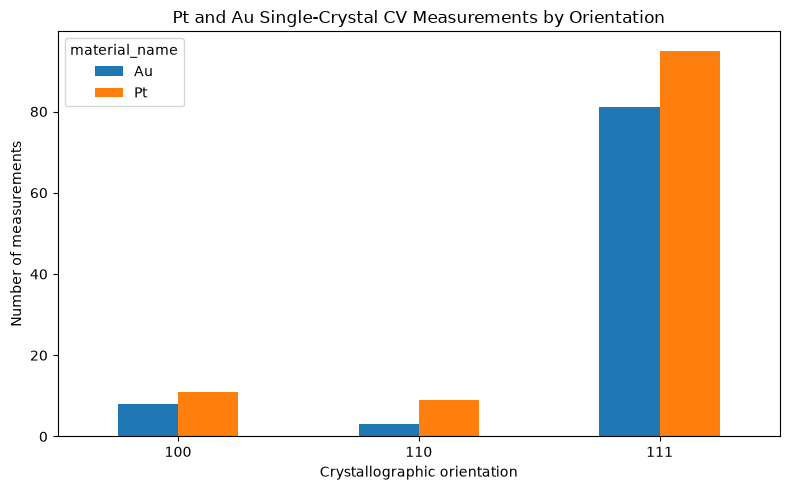

In [ ]:
# Pt and Au Single-Crystal CV Measurements by Orientation 
import matplotlib.pyplot as plt

q1_plot = q1_result.pivot(
    index="orientation_name",
    columns="material_name",
    values="measurement_count"
)

q1_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Crystallographic orientation")
plt.ylabel("Number of measurements")
plt.title("Pt and Au Single-Crystal CV Measurements by Orientation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#  Query_scan - Statistical summary of material name, their orientation, and their corresponding scan_rate_category and the measurement_count
query_scan = """
SELECT
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category,
    COUNT(*) AS measurement_count
FROM measurements AS me
JOIN materials AS mat
    ON me.material_id = mat.material_id
JOIN orientations AS o
    ON me.orientation_id = o.orientation_id
GROUP BY
    mat.material_name,
    o.orientation_name,
    me.scan_rate_category
ORDER BY
    mat.material_name,
    o.orientation_name;
"""

scan_result = pd.read_sql_query(query_scan, connection)

scan_result.head(20)

,material_name,orientation_name,scan_rate_category,measurement_count
0,Au,100,Low,8
1,Au,110,Low,1
2,Au,110,Medium,2
3,Au,111,High,9
4,Au,111,Low,54
5,Au,111,Medium,18
6,Pt,100,Medium,11
7,Pt,110,Low,1
8,Pt,110,Medium,8
9,Pt,111,High,2


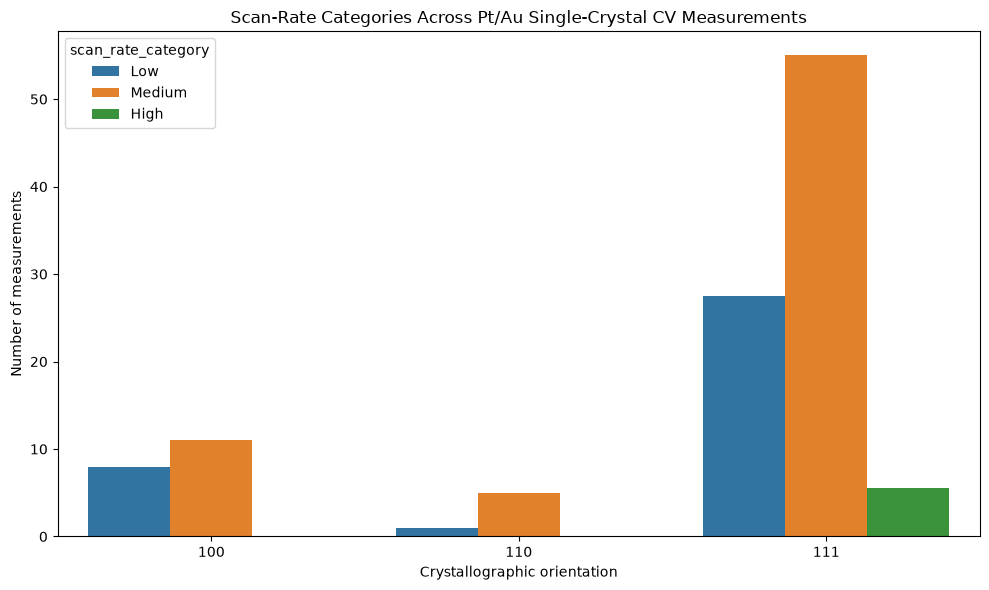

In [ ]:
# Scan-rate categories across Pt/Au single-crystal CV measurements
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=scan_result,
    x="orientation_name",
    y="measurement_count",
    hue="scan_rate_category",
    errorbar=None
)

plt.xlabel("Crystallographic orientation")
plt.ylabel("Number of measurements")
plt.title("Scan-Rate Categories Across Pt/Au Single-Crystal CV Measurements")
plt.tight_layout()
plt.show()